In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import astropy.time

# ─────────────────────────────────────────────────────────────────────────────
# Output folder for the 1-year plots
# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR = "plot_1year"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# Step 1: Total pointings per day from step1 shell_001
# ─────────────────────────────────────────────────────────────────────────────
print("Loading total pointings from step1 shell_001 ...")

shell1_csvs = glob.glob("streak_output_sgp4/streak_results_shell_001.csv")

total_records = []
for path in shell1_csvs:
    df = pd.read_csv(path, usecols=["observationId", "observationStartMJD"])
    df["date"] = df["observationStartMJD"].apply(
        lambda m: astropy.time.Time(m, format="mjd", scale="utc").iso[:10]
    )
    daily = df.groupby("date")["observationId"].nunique().reset_index()
    daily.columns = ["date", "n_total"]
    total_records.append(daily)
    del df

total_df = (pd.concat(total_records, ignore_index=True)
              .groupby("date")["n_total"].sum()
              .reset_index()
              .sort_values("date")
              .reset_index(drop=True))

print(f"  {len(total_df)} days, {total_df['n_total'].sum():,} total pointings")

# 365-day window, fixed to the requested start date (not derived from the
# data's first date).
first_date  = pd.Timestamp("2026-06-29")
cutoff_date = pd.Timestamp("2027-06-29")  # exclusive upper bound -> last day kept is 2027-06-28
print(f"  Restricting to {first_date.date()} .. {(cutoff_date - pd.Timedelta(days=1)).date()} "
      f"(365-day window starting {first_date.date()})")

# ─────────────────────────────────────────────────────────────────────────────
# Step 2: Streaked pointings (any streak) and sunlit streaked pointings
# Load step2 files one day at a time — only the files inside the 365-day
# window are read, so a 10-year run doesn't pay to load ~9 years of data
# it will just throw away later.
# ─────────────────────────────────────────────────────────────────────────────
print("\nLoading step2 day CSVs ...")

all_day_csvs = sorted(glob.glob("step2_output/streak_trajectories_*.csv"))
all_day_csvs = [p for p in all_day_csvs if "_azel" not in p]
print(f"  Found {len(all_day_csvs)} day CSV(s) total")

def _file_date(path):
    date_str = (os.path.basename(path)
                .replace("streak_trajectories_", "")
                .replace(".csv", ""))
    try:
        return pd.to_datetime(date_str)
    except Exception:
        return None

day_csvs_in_window = []
for p in all_day_csvs:
    d = _file_date(p)
    if d is not None and first_date <= d < cutoff_date:
        day_csvs_in_window.append(p)

all_day_csvs = day_csvs_in_window
print(f"  Keeping {len(all_day_csvs)} day CSV(s) inside the 365-day window")

streak_records = []
for i, path in enumerate(all_day_csvs):
    date_str = (os.path.basename(path)
                .replace("streak_trajectories_", "")
                .replace(".csv", ""))
    try:
        df = pd.read_csv(path, usecols=["pointing_id", "in_fov", "sunlit"])

        # Any streak — satellite was in FOV regardless of sunlit
        n_streaked = df[df["in_fov"]]["pointing_id"].nunique()

        # Sunlit streak — satellite in FOV AND illuminated by Sun
        sunlit_mask = (
            df["in_fov"] &
            (df["sunlit"].astype(str).str.lower() == "true")
        )
        n_sunlit_streaked = df[sunlit_mask]["pointing_id"].nunique()

        streak_records.append({
            "date":              date_str,
            "n_streaked":        n_streaked,
            "n_sunlit_streaked": n_sunlit_streaked,
        })
        del df

        if (i + 1) % 100 == 0 or i == len(all_day_csvs) - 1:
            print(f"  {i+1}/{len(all_day_csvs)}  {date_str}  "
                  f"any={n_streaked:,}  sunlit={n_sunlit_streaked:,}")

    except Exception as e:
        print(f"  [WARN] {date_str}: {e}")

streak_df = pd.DataFrame(streak_records).sort_values("date").reset_index(drop=True)

# ─────────────────────────────────────────────────────────────────────────────
# Merge
# ─────────────────────────────────────────────────────────────────────────────
summary = total_df.merge(streak_df, on="date", how="left")
summary["n_streaked"]        = summary["n_streaked"].fillna(0).astype(int)
summary["n_sunlit_streaked"] = summary["n_sunlit_streaked"].fillna(0).astype(int)
summary["pct_any"]    = 100.0 * summary["n_streaked"]        / summary["n_total"]
summary["pct_sunlit"] = 100.0 * summary["n_sunlit_streaked"] / summary["n_total"]
summary["date"]       = pd.to_datetime(summary["date"])
summary = summary.sort_values("date").reset_index(drop=True)

# Reindex to full date range so missing days are explicit NaN gaps
full_dates = pd.date_range(summary["date"].min(), summary["date"].max(), freq="D")
summary = summary.set_index("date").reindex(full_dates).reset_index()
summary.rename(columns={"index": "date"}, inplace=True)

# ─────────────────────────────────────────────────────────────────────────────
# Restrict to the 365-day window (first_date/cutoff_date were already
# computed above, before the step2 loop, so the file reads were limited too).
# total_df itself can still span the full multi-year dataset since Step 1
# only reads one small file, so we still trim summary here.
# ─────────────────────────────────────────────────────────────────────────────
summary = summary[(summary["date"] >= first_date) & (summary["date"] < cutoff_date)].reset_index(drop=True)

print(f"\nUsing data from {first_date.date()} to {summary['date'].max().date()} "
      f"(365-day window starting {first_date.date()})")

print(f"\n{'─'*60}")
print(f"  Mean % any streak    : {summary['pct_any'].mean():.1f}%")
print(f"  Mean % sunlit streak : {summary['pct_sunlit'].mean():.1f}%")
print(f"{'─'*60}")

# ─────────────────────────────────────────────────────────────────────────────
# Helper: plot a line skipping NaN gaps (so missing days don't connect)
# ─────────────────────────────────────────────────────────────────────────────
def plot_with_gaps(ax, dates, values, **kwargs):
    """Plot line separately for each contiguous non-NaN segment."""
    dates = np.array(dates)
    values = np.array(values, dtype=float)
    valid = ~np.isnan(values)
    if not valid.any():
        return
    changes = np.diff(valid.astype(int))
    starts = np.where(np.concatenate([[valid[0]], changes == 1]))[0]
    ends   = np.where(np.concatenate([changes == -1, [valid[-1]]]))[0]
    for i, (s, e) in enumerate(zip(starts, ends)):
        seg_kwargs = dict(kwargs)
        if i > 0:
            seg_kwargs.pop("label", None)
        ax.plot(dates[s:e+1], values[s:e+1], **seg_kwargs)

def style_month_axis(ax):
    """Monthly ticks — appropriate now that the window is a single year."""
    locator       = mdates.MonthLocator()
    formatter     = mdates.DateFormatter("%b %Y")
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.tick_params(axis='x', which='major', length=8, labelsize=16, rotation=45)

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Daily resolution
# ─────────────────────────────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 20, 'legend.fontsize': 16})

fig1, axes1 = plt.subplots(2, 1, figsize=(22, 12), sharex=True)
fig1.suptitle(
    "Rubin/LSST — Pointings Affected by Satellite Streaks (Daily)\n"
    "(All 94 SXODC Shells Combined)",
    fontsize=22, fontweight="bold"
)

ax1 = axes1[0]
ax1.bar(summary["date"], summary["n_total"],
        width=1.0, color="steelblue", alpha=0.5, label="Total pointings",
        rasterized=True)
ax1.bar(summary["date"], summary["n_streaked"],
        width=1.0, color="tomato", alpha=0.7, label="Any streak in FOV",
        rasterized=True)
ax1.bar(summary["date"], summary["n_sunlit_streaked"],
        width=1.0, color="darkred", alpha=0.9, label="Sunlit streak (visible)",
        rasterized=True)
ax1.set_ylabel("Number of Pointings")
ax1.legend(loc="upper right")
ax1.grid(axis="y", alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax2 = axes1[1]
plot_with_gaps(ax2, summary["date"], summary["pct_any"],
               color="green", linewidth=0.8, label="Any streak")
plot_with_gaps(ax2, summary["date"], summary["pct_sunlit"],
               color="red", linewidth=0.8, label="Sunlit streak (visible)")
ax2.set_ylabel("% Pointings")
ax2.set_xlabel("Date")
ax2.set_ylim(0, 105)
ax2.legend(loc="upper right")
ax2.grid(axis="y", alpha=0.3)
style_month_axis(ax2)

plt.tight_layout()
daily_out_path = os.path.join(OUTPUT_DIR, "streak_fraction_sunlit_daily.png")
plt.savefig(daily_out_path, dpi=150, bbox_inches="tight")
plt.close(fig1)
print(f"\nSaved: {daily_out_path}")

# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Weekly resolution (TOTAL summed over each calendar week)
# ─────────────────────────────────────────────────────────────────────────────
weekly = (
    summary.set_index("date")[["n_total", "n_streaked", "n_sunlit_streaked"]]
    .resample("W")
    .sum(numeric_only=True)   # sum, not mean — true weekly totals
    .reset_index()
)

# Recompute percentages from the SUMMED counts (not an average of daily %)
weekly["pct_any"]    = 100.0 * weekly["n_streaked"]        / weekly["n_total"]
weekly["pct_sunlit"] = 100.0 * weekly["n_sunlit_streaked"] / weekly["n_total"]

fig2, axes2 = plt.subplots(2, 1, figsize=(22, 12), sharex=True)
fig2.suptitle(
    "Rubin/LSST — Pointings Affected by Satellite Streaks (Weekly Totals)\n"
    "(All 94 SXODC Shells Combined)",
    fontsize=22, fontweight="bold"
)

ax3 = axes2[0]
ax3.bar(weekly["date"], weekly["n_total"],
        width=6.0, color="steelblue", alpha=0.5, label="Total pointings")
ax3.bar(weekly["date"], weekly["n_streaked"],
        width=6.0, color="tomato", alpha=0.7, label="Any streak in FOV")
ax3.bar(weekly["date"], weekly["n_sunlit_streaked"],
        width=6.0, color="darkred", alpha=0.9, label="Sunlit streak (visible)")
ax3.set_ylabel("Total Number of Pointings / Week")
ax3.legend(loc="upper right")
ax3.grid(axis="y", alpha=0.3)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax4 = axes2[1]
plot_with_gaps(ax4, weekly["date"], weekly["pct_any"],
               color="green", linewidth=1.5, marker="o", markersize=3,
               label="Any streak")
plot_with_gaps(ax4, weekly["date"], weekly["pct_sunlit"],
               color="red", linewidth=1.5, marker="o", markersize=3,
               label="Sunlit streak (visible)")
ax4.set_ylabel("% Pointings")
ax4.set_xlabel("Date")
ax4.set_ylim(0, 105)
ax4.legend(loc="upper right")
ax4.grid(axis="y", alpha=0.3)
style_month_axis(ax4)

plt.tight_layout()
weekly_out_path = os.path.join(OUTPUT_DIR, "streak_fraction_sunlit_weekly_total.png")
plt.savefig(weekly_out_path, dpi=150, bbox_inches="tight")
plt.close(fig2)
print(f"Saved: {weekly_out_path}")

Loading total pointings from step1 shell_001 ...


/u/njangid2/.conda/envs/my.anaconda/lib/python3.12/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "d2dtf" yielded 1 of "dubious year (Note 5)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


  2885 days, 1,844,571 total pointings
  Restricting to 2026-06-29 .. 2027-06-28 (365-day window starting 2026-06-29)

Loading step2 day CSVs ...
  Found 2885 day CSV(s) total
  Keeping 300 day CSV(s) inside the 365-day window
  100/300  2026-11-09  any=456  sunlit=109
  200/300  2027-02-28  any=615  sunlit=88
  300/300  2027-06-10  any=98  sunlit=52

Using data from 2026-06-29 to 2027-06-28 (365-day window starting 2026-06-29)

────────────────────────────────────────────────────────────
  Mean % any streak    : 63.9%
  Mean % sunlit streak : 21.6%
────────────────────────────────────────────────────────────

Saved: plot_1year/streak_fraction_sunlit_daily.png
Saved: plot_1year/streak_fraction_sunlit_weekly_total.png


Scanning step4b files to determine 365-day window ...
Found 2885 bright_corrected files total
365-day window: 2026-06-17 to 2027-06-16 (365-day window starting 2026-06-17)
Keeping 310 of 2885 bright_corrected files

  50/310  2026-08-13  streaks so far: 1,213,938
  100/310  2026-10-28  streaks so far: 2,195,963
  150/310  2026-12-21  streaks so far: 4,066,658
  200/310  2027-02-16  streaks so far: 5,889,762
  250/310  2027-04-09  streaks so far: 7,605,821
  300/310  2027-05-31  streaks so far: 8,935,207
  310/310  2027-06-10  streaks so far: 9,169,751
layer
H-LEO-30    2851652
SSO-99      2410535
LEO-30      2092171
SSO-97      1815393
Name: count, dtype: int64

Total streaks (mag < 12.5) : 9,169,751
Min mag   : 1.358
Max mag   : 12.500
Mean mag  : 4.975
Median mag: 4.736
mag < 2   : 229,372  (2.501%)
mag < 7   : 7,698,156  (83.952%)
  CPS  LEO-30      700 km  →  mag 7.26
  CPS  H-LEO-30    960 km  →  mag 7.60
  CPS  SSO-97      725 km  →  mag 7.30
  CPS  SSO-99      985 km  →  mag 7.6

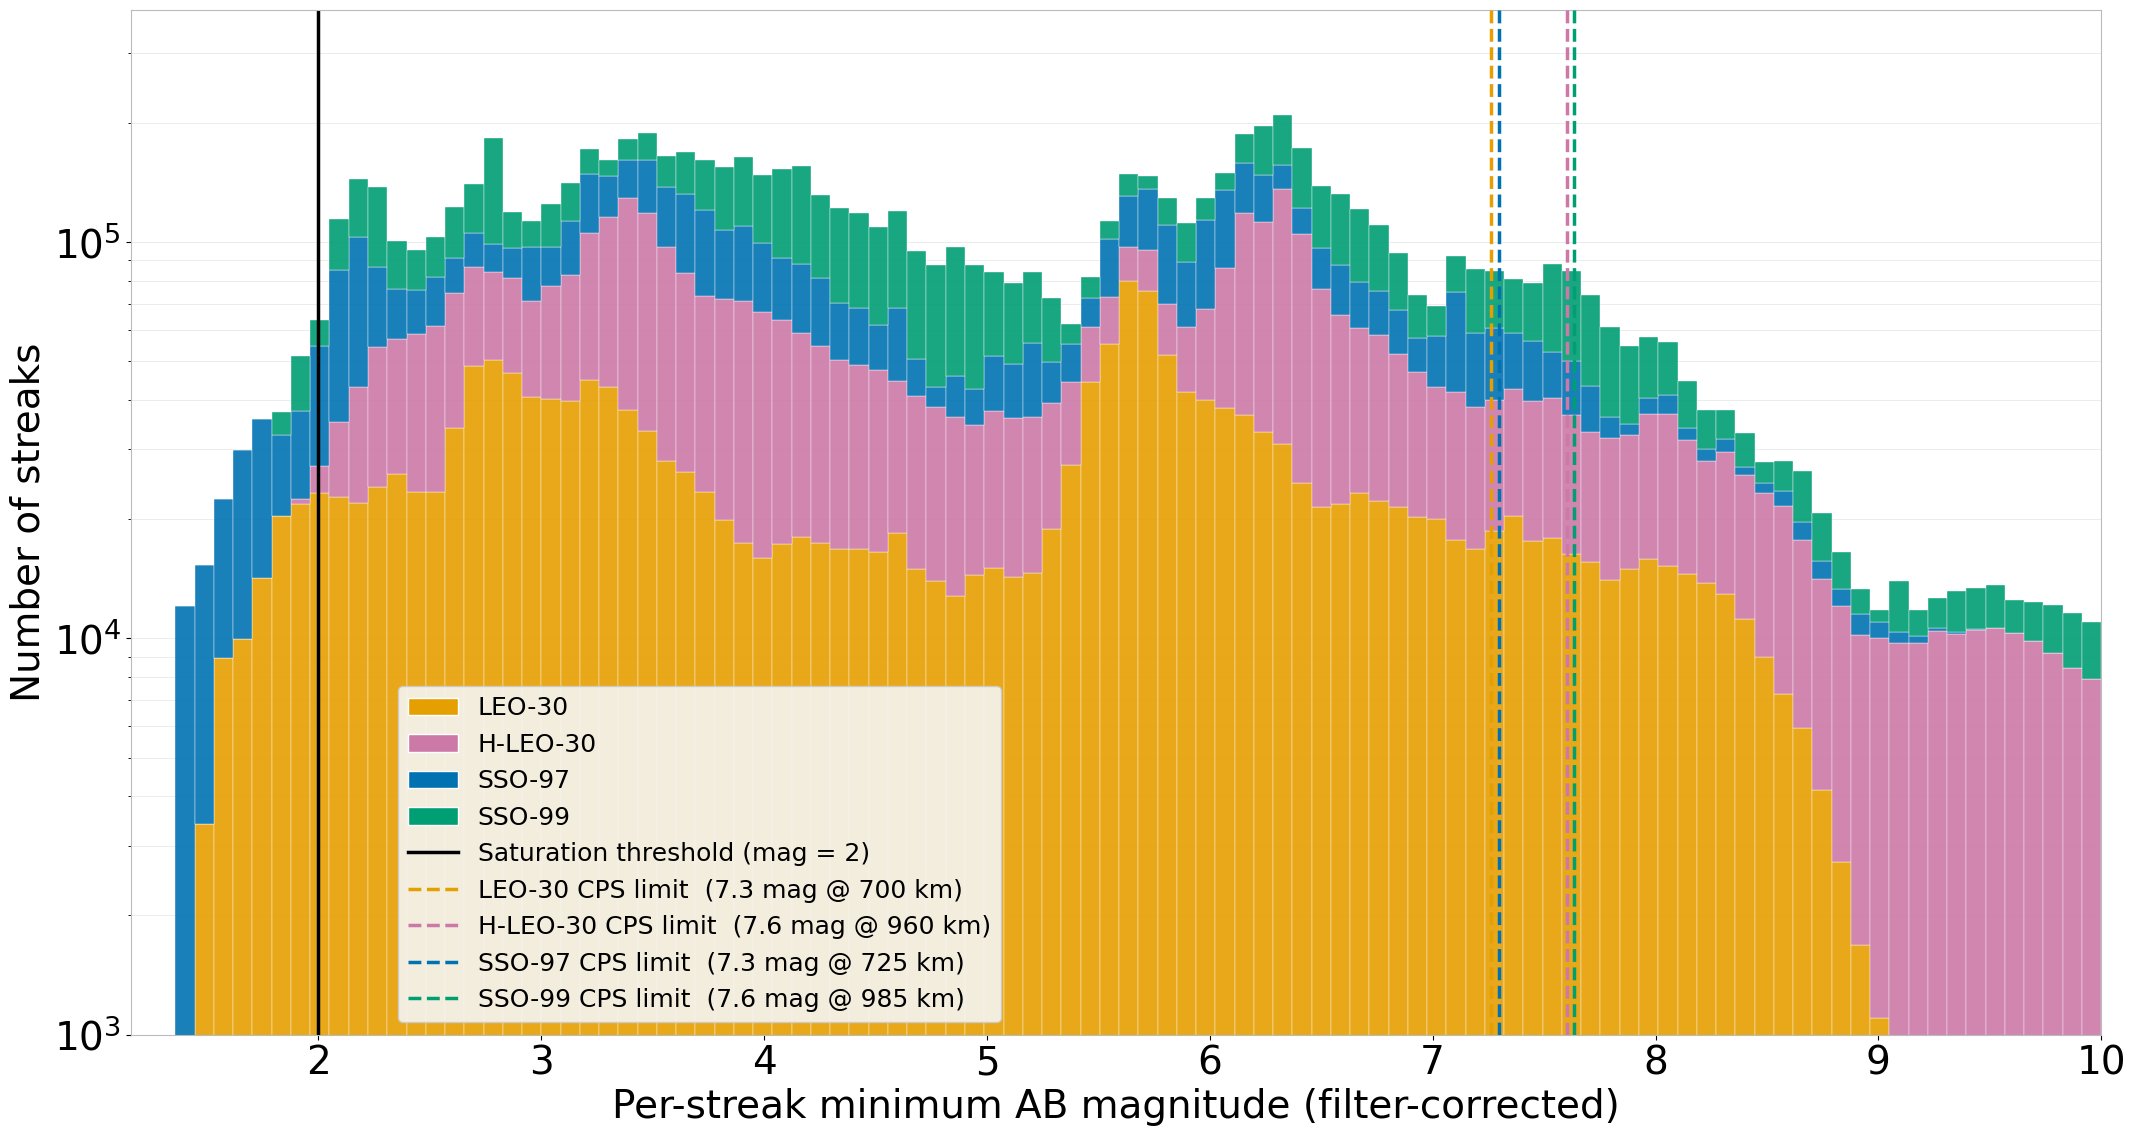


[SAVED] plot_1year/brightness_histogram_stacked_filter.png


In [1]:
"""
plot_brightness_histogram_stacked.py
─────────────────────────────────────────────────────────────────────────────
Brightness histogram of per-streak minimum AB magnitude.
  - Stacked bars: each shell layer shown in its own color (Wong 2011 palette)
  - Vertical dashed line at mag = 2  (detector saturation)
  - Per-shell vertical dashed lines at altitude-scaled CPS mag-7 limit
      CPS reference: mag 7.0 at 550 km
      scaled limit : mag_cps(h) = 7.0 + 5 * log10(h / 550)
  - No title; all stats written to caption string + saved as .txt
  - Restricted to the first 365 days of data (calendar span from the first
    available date), and only files inside that window are read.
─────────────────────────────────────────────────────────────────────────────
"""

import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────

STEP2_DIR   = "step2_output"
STEP4_DIR   = "step4b_output_rad"                          # ← step4b corrected files
OUTPUT_DIR  = "plot_1year"
OUT_FILE    = os.path.join(OUTPUT_DIR, "brightness_histogram_stacked_filter.png")
CAPTION_TXT = os.path.join(OUTPUT_DIR, "brightness_histogram_caption_filter.txt")

os.makedirs(OUTPUT_DIR, exist_ok=True)

N_BINS      = 100
MAG_MAX     = 10.0
LUMOS_FLOOR = 12.5

# Representative altitude (km) for each shell — used for CPS scaling
SHELL_ALTITUDES = {
    "LEO-30":   700,
    "H-LEO-30": 960,
    "SSO-97":   725,
    "SSO-99":   985,
}
CPS_REF_MAG = 7.0
CPS_REF_ALT = 550.0


def cps_mag(alt_km):
    return CPS_REF_MAG + 2.5 * np.log10(alt_km / CPS_REF_ALT)

# ─────────────────────────────────────────────────────────────────────────────
# Colours — Wong (2011) colorblind-safe
# ─────────────────────────────────────────────────────────────────────────────

LAYER_COLORS = {
    "LEO-30":   "#E69F00",
    "H-LEO-30": "#CC79A7",
    "SSO-97":   "#0072B2",
    "SSO-99":   "#009E73",
}

LAYER_ORDER = ["LEO-30", "H-LEO-30", "SSO-97", "SSO-99"]

def shell_id_to_layer(shell_id):
    if  1 <= shell_id <= 25:  return "LEO-30"
    if 26 <= shell_id <= 50:  return "H-LEO-30"
    if 51 <= shell_id <= 72:  return "SSO-97"
    if 73 <= shell_id <= 94:  return "SSO-99"
    return "LEO-30"

def layer_from_sat_name(sat_name):
    try:
        shell_id = int(str(sat_name)[2:4])
        return shell_id_to_layer(shell_id)
    except Exception:
        return "LEO-30"

# ─────────────────────────────────────────────────────────────────────────────
# Restrict to the first 365 days (calendar span from the first date found
# among the step4b files) — filtering happens BEFORE any CSV is read so a
# multi-year dataset doesn't pay the cost of loading years it won't use.
# ─────────────────────────────────────────────────────────────────────────────

print("Scanning step4b files to determine 365-day window ...")

step4_csvs_all = sorted(glob.glob(
    os.path.join(STEP4_DIR, "streak_trajectories_*_bright_corrected.csv")
))
print(f"Found {len(step4_csvs_all)} bright_corrected files total")

def _file_date(path):
    date_str = (os.path.basename(path)
                .replace("streak_trajectories_", "")
                .replace("_bright_corrected.csv", ""))
    try:
        return pd.to_datetime(date_str), date_str
    except Exception:
        return None, date_str

dated_paths = [_file_date(p) + (p,) for p in step4_csvs_all]
dated_paths = [(d, s, p) for (d, s, p) in dated_paths if d is not None]

first_date  = min(d for d, _, _ in dated_paths)
cutoff_date = first_date + pd.Timedelta(days=365)

step4_csvs = [p for (d, s, p) in dated_paths if first_date <= d < cutoff_date]

print(f"365-day window: {first_date.date()} to {(cutoff_date - pd.Timedelta(days=1)).date()} "
      f"(365-day window starting {first_date.date()})")
print(f"Keeping {len(step4_csvs)} of {len(step4_csvs_all)} bright_corrected files")

# ─────────────────────────────────────────────────────────────────────────────
# Collect per-streak magnitudes WITH layer labels
# ─────────────────────────────────────────────────────────────────────────────

print("\nCollecting per-streak brightness values ...")

records = []

for i, bright_path in enumerate(step4_csvs):
    date_str = (os.path.basename(bright_path)
                .replace("streak_trajectories_", "")
                .replace("_bright_corrected.csv", ""))

    step2_path = os.path.join(STEP2_DIR, f"streak_trajectories_{date_str}.csv")
    if not os.path.isfile(step2_path):
        print(f"  [SKIP] {date_str} — step2 missing")
        continue

    step2  = pd.read_csv(step2_path,
                         usecols=["pointing_id", "sat_name", "in_fov", "sunlit"])
    bright = pd.read_csv(bright_path,
                         usecols=["ab_magnitude_corrected"])

    if len(step2) != len(bright):
        print(f"  [SKIP] {date_str} — row count mismatch")
        continue

    step2["ab_magnitude"] = bright["ab_magnitude_corrected"].values

    # Keep only sunlit + in_fov + valid brightness + below lumos floor
    mask = (
        (step2["in_fov"].astype(str).str.lower()  == "true") &
        (step2["sunlit"].astype(str).str.lower()  == "true") &
        (step2["ab_magnitude"].notna()) &
        (step2["ab_magnitude"] < LUMOS_FLOOR)
    )
    df = step2[mask].copy()

    if df.empty:
        continue

    df["layer"] = df["sat_name"].apply(layer_from_sat_name)

    streak_df = (
        df.groupby(["pointing_id", "sat_name", "layer"])["ab_magnitude"]
        .min()
        .reset_index()
    )
    records.append(streak_df[["ab_magnitude", "layer"]])

    if (i + 1) % 50 == 0 or i == len(step4_csvs) - 1:
        total_so_far = sum(len(r) for r in records)
        print(f"  {i+1}/{len(step4_csvs)}  {date_str}  "
              f"streaks so far: {total_so_far:,}")

all_df = pd.concat(records, ignore_index=True)
print(all_df["layer"].value_counts())
all_mags = all_df["ab_magnitude"].values

print(f"\nTotal streaks (mag < {LUMOS_FLOOR}) : {len(all_mags):,}")
print(f"Min mag   : {all_mags.min():.3f}")
print(f"Max mag   : {all_mags.max():.3f}")
print(f"Mean mag  : {all_mags.mean():.3f}")
print(f"Median mag: {np.median(all_mags):.3f}")
print(f"mag < 2   : {(all_mags < 2.0).sum():,}  "
      f"({100*(all_mags < 2.0).mean():.3f}%)")
print(f"mag < 7   : {(all_mags < 7.0).sum():,}  "
      f"({100*(all_mags < 7.0).mean():.3f}%)")

# ─────────────────────────────────────────────────────────────────────────────
# Prepare data
# ─────────────────────────────────────────────────────────────────────────────

plot_df   = all_df[all_df["ab_magnitude"] < MAG_MAX].copy()
plot_mags = plot_df["ab_magnitude"].values

layer_mag_arrays = [
    plot_df.loc[plot_df["layer"] == lyr, "ab_magnitude"].values
    for lyr in LAYER_ORDER
]
layer_colors = [LAYER_COLORS[lyr] for lyr in LAYER_ORDER]

# ─────────────────────────────────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({'font.size': 28, 'legend.fontsize': 20})
fig, ax = plt.subplots(figsize=(22, 12))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

bin_edges = np.linspace(plot_mags.min(), MAG_MAX, N_BINS + 1)

ax.hist(
    layer_mag_arrays,
    bins=bin_edges,
    stacked=True,
    color=layer_colors,
    edgecolor='white',
    linewidth=0.3,
    alpha=0.90,
    label=LAYER_ORDER,
)

ax.set_yscale('log')
ax.set_ylim(bottom=1e3)

# Saturation line
ax.axvline(x=2.0, color='black', linewidth=2.5, linestyle='-')

# Per-shell CPS lines
cps_legend_entries = []
for lyr in LAYER_ORDER:
    alt   = SHELL_ALTITUDES[lyr]
    m_cps = cps_mag(alt)
    color = LAYER_COLORS[lyr]
    ax.axvline(x=m_cps, color=color, linewidth=2.5, linestyle='--', zorder=5)
    cps_legend_entries.append(
        Line2D([0], [0], color=color, lw=2.5, linestyle='--',
               label=f'{lyr} CPS limit  ({m_cps:.1f} mag @ {alt} km)')
    )
    print(f"  CPS  {lyr:10s}  {alt} km  →  mag {m_cps:.2f}")

ax.set_xlabel('Per-streak minimum AB magnitude (filter-corrected)', color='black')
ax.set_ylabel('Number of streaks', color='black')
ax.set_xlim(plot_mags.min() - 0.2, MAG_MAX)
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_edgecolor('#BBBBBB')
ax.yaxis.grid(True, which='both', color='#DDDDDD',
              linewidth=0.5, linestyle='-', alpha=0.8)
ax.set_axisbelow(True)

bar_entries = [
    Patch(facecolor=LAYER_COLORS[lyr], edgecolor='white', label=lyr)
    for lyr in LAYER_ORDER
]
sat_entry = Line2D([0], [0], color='black', lw=2.5, linestyle='-',
                   label='Saturation threshold (mag = 2)')

ax.legend(handles=bar_entries + [sat_entry] + cps_legend_entries,
          facecolor='#F5F5F5', edgecolor='#CCCCCC',
          labelcolor='black', framealpha=0.90,
          fontsize=18, loc='lower left',
          bbox_to_anchor=(2.3, 0),
          bbox_transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig(OUT_FILE, dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(f"\n[SAVED] {OUT_FILE}")

  Step 1: collecting per-pointing brightness records …
Found 2885 day CSV(s) total
Keeping 300 day CSV(s) inside the 365-day window (2026-06-29 to 2027-06-28)
  100/300 days processed …
  200/300 days processed …
  300/300 days processed …

Collected 32,163 per-pointing records
  Date range  : 2026-06-29 → 2027-06-10
  Hour range  : 0.00 → 24.00 UTC-3
  Mag range   : 1.36 → 28.93

  Step 2: plotting …


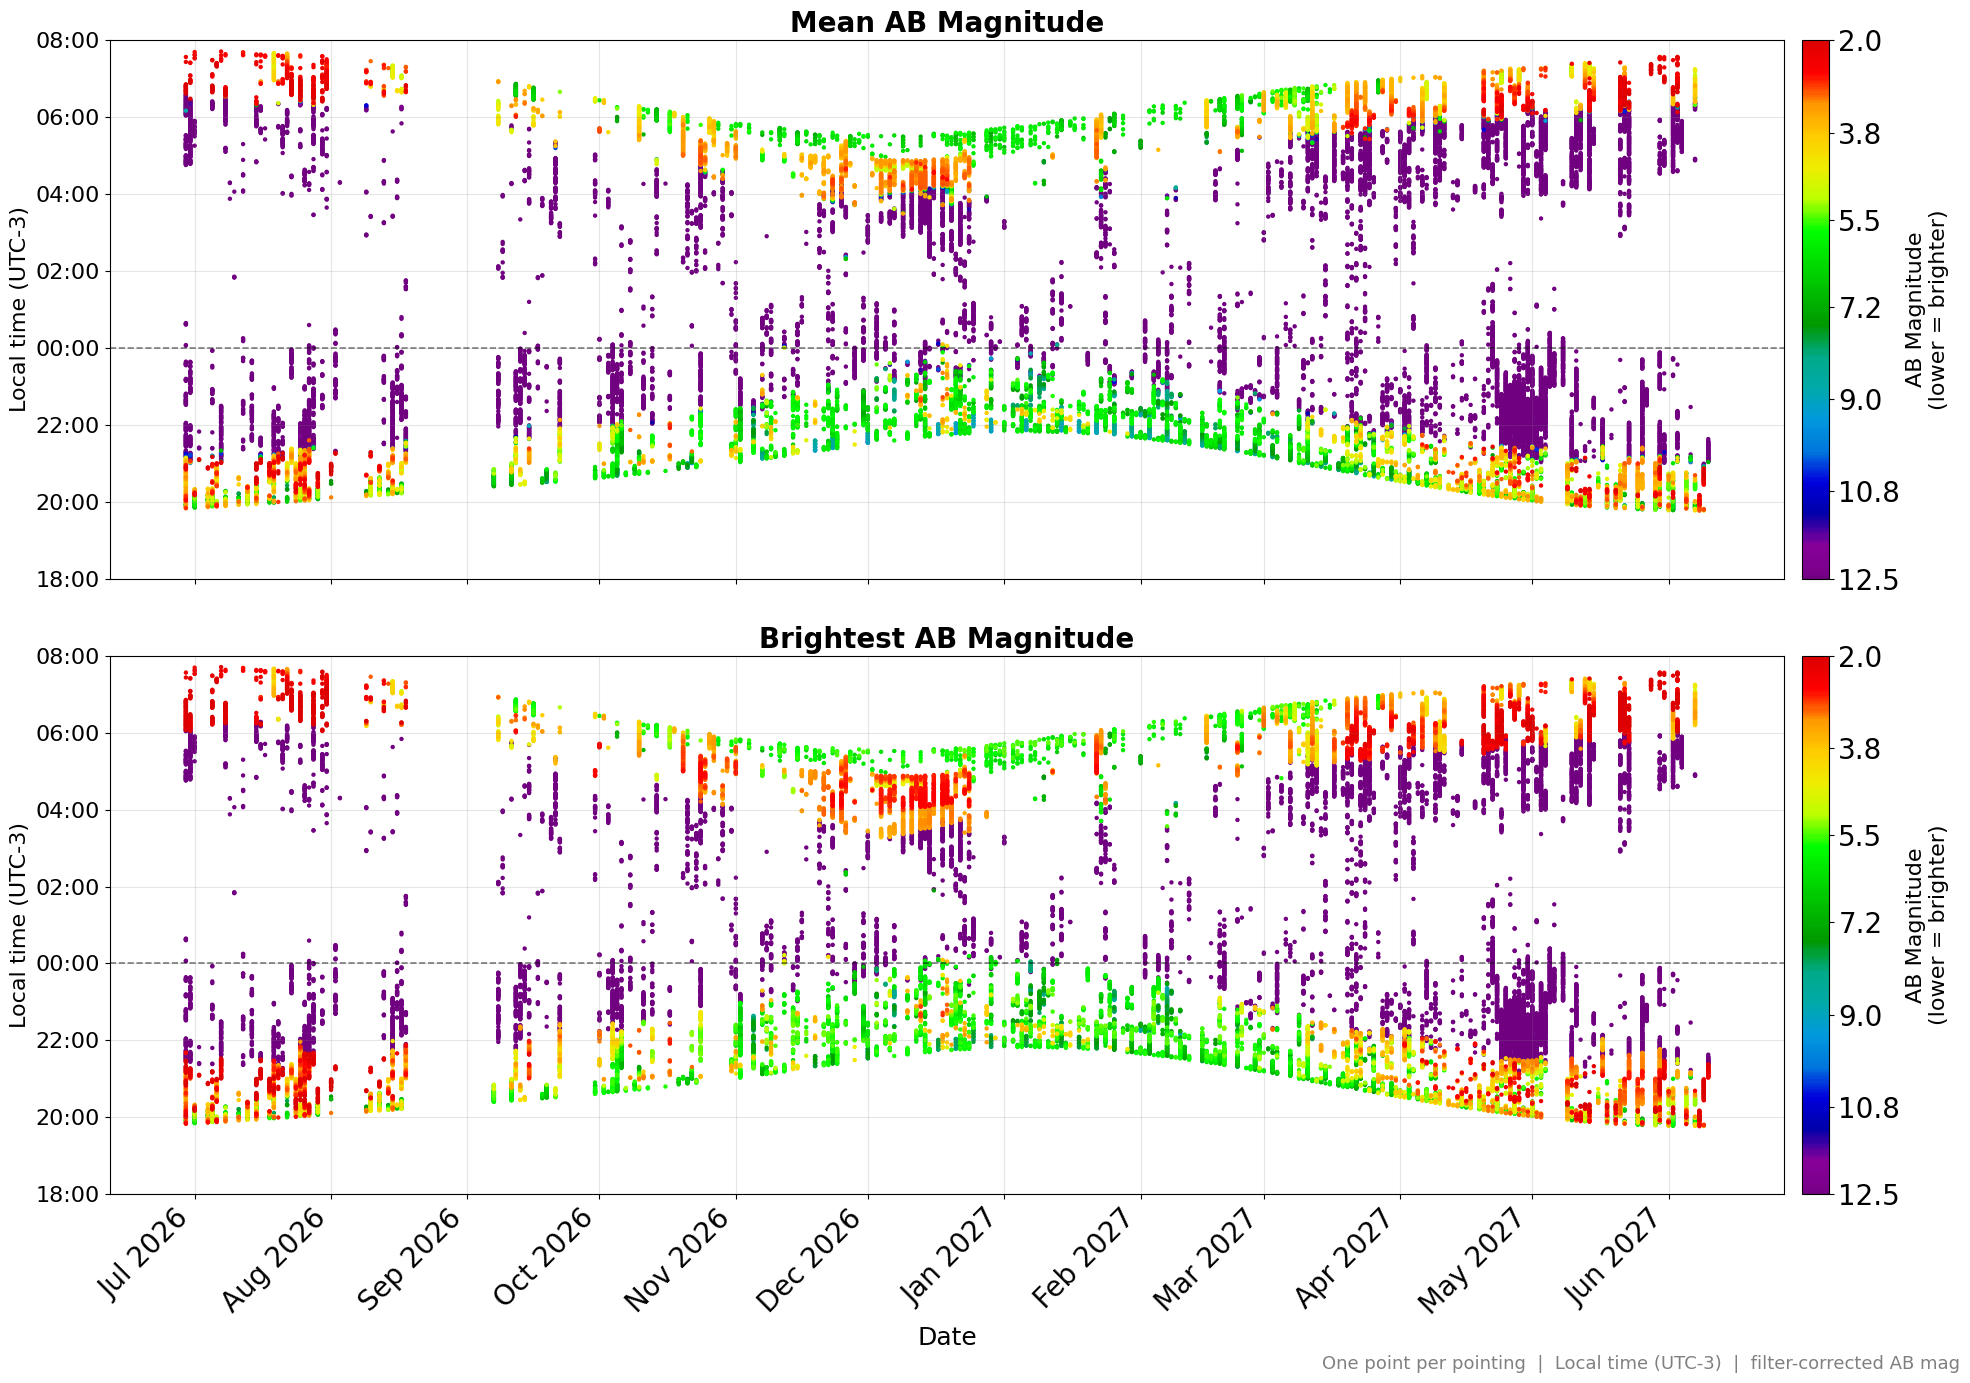


[SAVED] plot_1year/brightness_per_pointing_scatter_m3_rad_perpointing.png


In [2]:
"""
plot_brightness_per_pointing.py  –  Per-pointing scatter, mean + brightest panels
─────────────────────────────────────────────────────────────────────────────
Per-pointing counterpart of plot_brightness_heatmap.py. That script bins
every step2 row into (date, hour_bin) cells and aggregates mean/min AB
magnitude per cell. Here, each pointing_id is collapsed to a single point
instead: x = date, y = its local observing time (median across its rows),
color = AB magnitude. Multiple step2 rows for the same pointing_id (e.g.
multiple trajectory steps, or multiple streaks) are collapsed to one row
per pointing_id by taking the mean AB mag (-> "Mean" panel) and the min/
brightest AB mag (-> "Brightest" panel) — same role mean/min played in the
original binned version, just collapsed by pointing instead of by time bin.

IMPORTANT — row alignment with step4b sidecar
───────────────────────────────────────────────
step2_output/streak_trajectories_*.csv and
step4b_output_rad/streak_trajectories_*_bright_corrected.csv are row-aligned
(same row order, same length) — ab_magnitude_corrected at row i in the
sidecar corresponds to row i of the step2 file. So pointing_id must be
pulled from step2 BEFORE any filtering, then ab_magnitude attached by
direct positional alignment, exactly as the original script did for
t_mjd/hour binning.

WINDOW: restricted to a fixed 365-day window, 2026-06-29 to 2027-06-28.
Only the day CSVs inside that window are read — filtering happens BEFORE
any CSV is opened, so a multi-year dataset doesn't pay to load years of
data it won't use.
"""

import os, gc, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm


# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────

STEP2_DIRS  = ["step2_output"]
STEP4_DIR   = "step4b_output_rad"                          # ← step4b corrected files
OUTPUT_DIR  = "plot_1year"
OUTPUT_PNG  = os.path.join(OUTPUT_DIR, "brightness_per_pointing_scatter_m3_rad_perpointing.png")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Fixed 365-day window (same window used across the other plot_1year scripts)
FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def utc_hour_to_chile(utc_hour: float) -> float:
    """Convert a UTC fractional hour to local time using a fixed UTC-3 offset."""
    return (utc_hour - 3.0) % 24.0


def chile_hour_to_display(h: float) -> float:
    """
    Remap local hour so that:
      noon     (12) -> 0  / 24  (top & bottom edges)
      midnight (0)  -> 12       (centre)
    display = (real_hour - 12) % 24
    inverse : real  = (display + 12) % 24
    """
    return (h - 12.0) % 24.0


def _file_date(path):
    date_str = (os.path.basename(path)
                .replace("streak_trajectories_", "")
                .replace(".csv", ""))
    try:
        return pd.to_datetime(date_str)
    except Exception:
        return None


# ─────────────────────────────────────────────────────────────────────────────
# Step 1: collect per-pointing records day by day (no time binning)
# ─────────────────────────────────────────────────────────────────────────────

def collect_records(step2_dirs, step4_dir, first_date, cutoff_date):
    """
    Returns a DataFrame with one row per pointing_id (per date):
        pointing_id, date, hour_bin (local display hour), avg_mag, min_mag

    avg_mag = mean AB magnitude across that pointing's step2 rows
    min_mag = min (brightest) AB magnitude across that pointing's rows

    No time-bin aggregation — each pointing keeps its own observation time.

    Only files whose date falls in [first_date, cutoff_date) are read.
    """
    all_step2 = sorted(
        sum([glob.glob(os.path.join(d, "streak_trajectories_*.csv"))
             for d in step2_dirs], []),
        key=lambda p: os.path.basename(p)
    )
    # exclude azel / bright sidecar files
    all_step2 = [p for p in all_step2
                 if "_azel" not in p and "_bright" not in p]
    print(f"Found {len(all_step2)} day CSV(s) total")

    all_step2 = [p for p in all_step2
                 if (d := _file_date(p)) is not None and first_date <= d < cutoff_date]
    print(f"Keeping {len(all_step2)} day CSV(s) inside the 365-day window "
          f"({first_date.date()} to {(cutoff_date - pd.Timedelta(days=1)).date()})")

    records = []

    for i, step2_path in enumerate(all_step2):
        date_str = (os.path.basename(step2_path)
                    .replace("streak_trajectories_", "")
                    .replace(".csv", ""))

        # ── Read step4b corrected sidecar ─────────────────────────────────
        bright_path = os.path.join(
            step4_dir,
            f"streak_trajectories_{date_str}_bright_corrected.csv"
        )

        if not os.path.isfile(bright_path):
            continue

        try:
            df  = pd.read_csv(step2_path,  usecols=["pointing_id", "t_mjd"])
            bdf = pd.read_csv(bright_path, usecols=["ab_magnitude_corrected"])
        except Exception as e:
            print(f"  [WARN] {date_str}: {e}")
            continue

        if len(df) != len(bdf):
            print(f"  [WARN] {date_str}: row count mismatch — skipping")
            del df, bdf
            gc.collect()
            continue

        # ── Positional alignment, BEFORE any filtering ─────────────────────
        # step2 and the step4b sidecar are row-aligned (same order, same
        # length), so attach ab_magnitude by position while pointing_id
        # and t_mjd are still at their original row indices.
        df["ab_magnitude"] = bdf["ab_magnitude_corrected"].values
        del bdf

        df = df[df["ab_magnitude"].notna()].copy()
        if df.empty:
            del df; gc.collect(); continue

        # UTC fractional hour for each row, converted to local time
        df["hour_utc"]   = (df["t_mjd"] % 1.0) * 24.0
        df["hour_local"] = utc_hour_to_chile(df["hour_utc"].values)

        # ── Collapse to one row per pointing_id (no time binning) ─────────
        agg = (df.groupby("pointing_id")
                 .agg(avg_mag=("ab_magnitude", "mean"),
                      min_mag=("ab_magnitude", "min"),
                      hour_bin=("hour_local", "median"))
                 .reset_index())
        agg["date"] = date_str

        records.append(agg)

        del df, agg
        gc.collect()

        if (i + 1) % 100 == 0 or i == len(all_step2) - 1:
            print(f"  {i+1}/{len(all_step2)} days processed …")

    if not records:
        raise RuntimeError("No records collected — check step4b output exists.")

    result = pd.concat(records, ignore_index=True)
    result["date"] = pd.to_datetime(result["date"])

    # In case the same pointing_id appears more than once across files
    # (shouldn't normally happen since pointings are day-scoped), keep
    # the last occurrence rather than silently duplicating points.
    result = result.drop_duplicates(["pointing_id", "date"], keep="last")

    print(f"\nCollected {len(result):,} per-pointing records")
    print(f"  Date range  : {result['date'].min().date()} → {result['date'].max().date()}")
    print(f"  Hour range  : {result['hour_bin'].min():.2f} → {result['hour_bin'].max():.2f} UTC-3")
    print(f"  Mag range   : {result['min_mag'].min():.2f} → {result['avg_mag'].max():.2f}")

    return result


# ─────────────────────────────────────────────────────────────────────────────
# Step 2: plot — scatter, two panels (mean + brightest), no binning/meshgrid
# ─────────────────────────────────────────────────────────────────────────────

def plot_scatter(records_df, output_png):
    """
    records_df: one row per pointing_id (per date) with columns
        date (datetime), hour_bin (float, local hour 0-24), avg_mag, min_mag
    """
    hours_display = chile_hour_to_display(records_df["hour_bin"].values)
    dates_mpl      = mdates.date2num(records_df["date"])

    n_days = (records_df["date"].max() - records_df["date"].min()).days
    # Widen proportionally for multi-year spans; cap so it doesn't get absurd
    fig_width = float(np.clip(20 * (n_days / 365.0), 20, 60))

    plt.rcParams.update({"font.size": 20})
    fig, axes = plt.subplots(2, 1, figsize=(fig_width, 14), sharex=True)
    fig.patch.set_facecolor("white")

    # Smaller points for dense multi-year scatters so panels don't saturate
    point_size = 10 if n_days <= 400 else 4

    panels = [
        (records_df["avg_mag"].values, "Mean AB Magnitude",      axes[0]),
        (records_df["min_mag"].values, "Brightest AB Magnitude", axes[1]),
    ]

    for vals, title, ax in panels:
        mask = ~np.isnan(vals)
        if not mask.any():
            ax.set_title(title + " (no data)", fontsize=20)
            continue

        x_panel = dates_mpl[mask]
        y_panel = hours_display[mask]
        c_panel = vals[mask]

        # ── Draw faintest first, brightest last ────────────────────────────
        # Lower AB magnitude = brighter. Sorting descending by magnitude
        # means high-mag (faint) points are plotted first and low-mag
        # (bright) points are plotted last, on top — so the brightest
        # points are never hidden under fainter ones.
        order   = np.argsort(c_panel)[::-1]   # descending: faint -> bright
        x_panel = x_panel[order]
        y_panel = y_panel[order]
        c_panel = c_panel[order]

        vmin = 2.0
        vmax = 12.5

        sc = ax.scatter(
            x_panel, y_panel, c=c_panel,
            cmap=turbo_clipped,
            vmin=vmin, vmax=vmax,
            s=point_size, linewidths=0, rasterized=True
        )

        cbar = fig.colorbar(sc, ax=ax, pad=0.01, fraction=0.02)
        cbar.set_label("AB Magnitude\n(lower = brighter)", fontsize=16)

        cbar_ticks = np.round(np.linspace(vmin, vmax, 7), 1).tolist()
        cbar.set_ticks(cbar_ticks)
        cbar.ax.invert_yaxis()
        ax.set_title(title, fontsize=20, fontweight="bold")
        ax.set_ylabel("Local time (UTC-3)", fontsize=16)
        ax.set_facecolor("white")

        y_lo, y_hi = 6.0, 20.0
        ax.set_ylim(y_lo, y_hi)
        tick_display = np.arange(y_lo, y_hi + 0.1, 2)
        tick_labels  = [f"{int((t + 12) % 24):02d}:00" for t in tick_display]
        ax.set_yticks(tick_display)
        ax.set_yticklabels(tick_labels, fontsize=16)

        ax.axhline(12, color="black", linewidth=1.2, linestyle="--", alpha=0.5)

        ax.grid(axis="both", alpha=0.2, color="gray")

    axes[1].set_xlabel("Date", fontsize=18)

    # ── Date tick strategy: month ticks for short spans, year ticks for long ──
    if n_days <= 400:
        axes[1].xaxis.set_major_locator(mdates.MonthLocator())
        axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    else:
        locator   = mdates.YearLocator()
        minor_loc = mdates.MonthLocator(bymonth=[4, 7, 10])
        formatter = mdates.ConciseDateFormatter(locator)
        axes[1].xaxis.set_major_locator(locator)
        axes[1].xaxis.set_minor_locator(minor_loc)
        axes[1].xaxis.set_major_formatter(formatter)
        axes[1].tick_params(axis="x", which="major", length=8, labelsize=18)
        axes[1].tick_params(axis="x", which="minor", length=4)

    plt.xticks(rotation=45, ha="right")

    fig.text(
        0.99, 0.005,
        "One point per pointing  |  Local time (UTC-3)  |  filter-corrected AB mag",
        ha="right", va="bottom", fontsize=13, color="gray"
    )

    plt.tight_layout()
    plt.savefig(output_png, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\n[SAVED] {output_png}")


# Take only the middle portion of nipy_spectral
turbo_clipped = LinearSegmentedColormap.from_list(
    "turbo_clipped",
    cm.nipy_spectral_r(np.linspace(0.1, 0.95, 256))
)


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    print("=" * 60)
    print("  Step 1: collecting per-pointing brightness records …")
    print("=" * 60)
    records_df = collect_records(
        step2_dirs  = STEP2_DIRS,
        step4_dir   = STEP4_DIR,
        first_date  = FIRST_DATE,
        cutoff_date = CUTOFF_DATE,
    )

    print("\n" + "=" * 60)
    print("  Step 2: plotting …")
    print("=" * 60)
    plot_scatter(
        records_df = records_df,
        output_png = OUTPUT_PNG,
    )

In [1]:
"""
step5_plot08_twilight.py
─────────────────────────────────────────────────────────────────────────────
Plot 08 only, restricted to TWILIGHT pointings: sun elevation between
0 deg and -25 deg (covers both evening (sunset) and morning (sunrise)
twilight, since the filter is on a sun_el_deg range, not direction of
travel).

WHERE SUN ELEVATION COMES FROM
────────────────────────────────
Sun elevation isn't in step2/v2/combined_loss output directly. It lives
in step3_output/sun_positions.csv (from step3b_sun_positions.py), keyed
by t_mjd — ONE row per unique timestamp across the whole survey, NOT per
pointing_id.

To get sun_el_deg per pointing_id, we:
    1. Read pointing_id -> pointing_mjd from each day's step2 file
       (pointing_mjd is the same for every row of a given pointing_id).
    2. Match pointing_mjd against sun_positions.csv's t_mjd using a
       nearest-timestamp join (pd.merge_asof) — pointing_mjd may not land
       on an exact t_mjd value that was sampled during the trajectory
       scan, but sun elevation changes negligibly over a single exposure,
       so nearest-match is accurate enough.
    3. Build one global pointing_id -> sun_el_deg lookup from this.

FILTER ORDER MATTERS
─────────────────────
We merge each night's pixel-loss-per-pointing (combined_loss winning over
v2, same priority as step5_pixel_loss_heatmap.py) with sun_el_deg FIRST,
then filter to -25 <= sun_el_deg <= 0, and ONLY THEN compute that night's
mean/max. Filtering after averaging would just give the same whole-night
average; filtering before means the mean/max reflect only the
twilight-time pointings, which is the entire point of this plot.

Nights with zero pointings in the twilight window are skipped (NaN),
so the line breaks naturally rather than dropping to 0.

WINDOW (this script, run standalone)
─────────────────────────────────────
When run as __main__, this plot is restricted to a fixed 365-day window,
2026-06-29 to 2027-06-28. Only step2/v2/combined_loss files whose date
falls in that window are read — filtering happens BEFORE any CSV is
opened, so a multi-year dataset doesn't pay to load years it won't use.
Output goes to step5_plots_rad/plot_1year/.

NOTE FOR IMPORTERS (e.g. step5_plot08_twilight_yearfold.py): the window
filtering is OPT-IN via the first_date/cutoff_date keyword args on
build_pointing_sun_el_lookup() and load_twilight_daily_pixel_loss().
Leaving them as None (the default) preserves the original full-range
behavior, so the year-fold script's across-year statistics are
unaffected by this script's window restriction.

USAGE
─────
    python step5_plot08_twilight.py
"""

import os, glob, re, gc
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
COMBINED_DIR = "step5_combined_loss_output_rad"
V2_DIR       = "step5_output_v2_rad"
STEP2_DIR    = "step2_output"
SUN_POS_PATH = "step3_output/sun_positions.csv"
PLOT_DIR     = "step5_plots_rad"
DPI          = 150

SUN_ALT_MIN  = -25.0   # degrees
SUN_ALT_MAX  =   0.0   # degrees

# Fixed 365-day window used only when this script is run standalone
# (see NOTE FOR IMPORTERS above — this does NOT affect the year-fold script).
FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def save(fig, name, plot_dir=PLOT_DIR):
    path = os.path.join(plot_dir, name)
    os.makedirs(plot_dir, exist_ok=True)
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved → {path}")


def get_date_from_filename(path):
    m = re.search(r"(\d{4}-\d{2}-\d{2})", os.path.basename(path))
    return m.group(1) if m else None


def _in_window(date_str, first_date, cutoff_date):
    if first_date is None and cutoff_date is None:
        return True
    try:
        d = pd.to_datetime(date_str)
    except Exception:
        return False
    if first_date is not None and d < first_date:
        return False
    if cutoff_date is not None and d >= cutoff_date:
        return False
    return True


def apply_date_locator(ax, n_days):
    """Month ticks for short spans, year ticks for long multi-year spans."""
    if n_days <= 400:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    else:
        locator   = mdates.YearLocator()
        minor_loc = mdates.MonthLocator(bymonth=[4, 7, 10])
        formatter = mdates.ConciseDateFormatter(locator)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_minor_locator(minor_loc)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis="x", which="major", length=8)
        ax.tick_params(axis="x", which="minor", length=4)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# ─────────────────────────────────────────────────────────────────────────────
# Sun elevation lookup: pointing_id -> sun_el_deg
# ─────────────────────────────────────────────────────────────────────────────

def build_pointing_sun_el_lookup(first_date=None, cutoff_date=None):
    """
    Builds a global dict: pointing_id (int) -> sun_el_deg (float).

    Step 1: collect pointing_id -> pointing_mjd from every step2 day file
            (pointing_mjd is constant across all rows of a pointing_id,
            so we just take the first value per group).
    Step 2: nearest-match pointing_mjd against sun_positions.csv's t_mjd
            via pd.merge_asof (sorted, direction='nearest').

    first_date/cutoff_date: optional window bounds ([first_date, cutoff_date)).
        Leave as None (default) to scan every step2 file, which is what
        the year-fold script relies on for its full multi-year statistics.
    """
    if not os.path.isfile(SUN_POS_PATH):
        raise FileNotFoundError(
            f"Not found: {SUN_POS_PATH} — run step3b_sun_positions.py first."
        )

    print(f"  Loading sun_positions.csv …")
    sun_df = pd.read_csv(SUN_POS_PATH, usecols=["t_mjd", "sun_el_deg"])
    sun_df = sun_df.sort_values("t_mjd").reset_index(drop=True)
    print(f"    {len(sun_df):,} unique timestamps")

    step2_paths = sorted(glob.glob(
        os.path.join(STEP2_DIR, "streak_trajectories_*.csv")))
    step2_paths = [p for p in step2_paths
                   if "_azel" not in p and "_bright" not in p and "_raft" not in p]
    if not step2_paths:
        raise FileNotFoundError(f"No step2 CSVs found in {STEP2_DIR}")

    if first_date is not None or cutoff_date is not None:
        n_before = len(step2_paths)
        step2_paths = [p for p in step2_paths
                       if _in_window(get_date_from_filename(p), first_date, cutoff_date)]
        print(f"  Window filter: keeping {len(step2_paths)} of {n_before} step2 files")

    print(f"  Collecting pointing_id -> pointing_mjd from "
          f"{len(step2_paths)} step2 day files …")

    pid_mjd_parts = []
    for i, p in enumerate(step2_paths):
        if os.path.getsize(p) == 0:
            continue
        try:
            df = pd.read_csv(p, usecols=["pointing_id", "pointing_mjd"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if df.empty:
            continue
        pid_mjd_parts.append(df.drop_duplicates("pointing_id"))
        if (i + 1) % 500 == 0 or i == len(step2_paths) - 1:
            print(f"    {i+1}/{len(step2_paths)} step2 files scanned …")

    pid_mjd = pd.concat(pid_mjd_parts, ignore_index=True)
    pid_mjd = pid_mjd.drop_duplicates("pointing_id").reset_index(drop=True)
    del pid_mjd_parts; gc.collect()
    print(f"    {len(pid_mjd):,} unique pointings collected")

    # ── Nearest-timestamp match against sun_positions ──────────────────────
    pid_mjd = pid_mjd.sort_values("pointing_mjd").reset_index(drop=True)
    matched = pd.merge_asof(
        pid_mjd, sun_df,
        left_on="pointing_mjd", right_on="t_mjd",
        direction="nearest"
    )

    lookup = dict(zip(matched["pointing_id"].astype(int),
                       matched["sun_el_deg"].astype(float)))
    print(f"    {len(lookup):,} pointing_id -> sun_el_deg entries built")
    return lookup

# ─────────────────────────────────────────────────────────────────────────────
# Loader — merged per-pointing pixel loss, filtered to twilight, per night
# ─────────────────────────────────────────────────────────────────────────────

def load_twilight_daily_pixel_loss(sun_el_lookup: dict, first_date=None, cutoff_date=None):
    """
    For every day v2 has output: merge that day's pointings with
    combined_loss's pointings (combined wins per pointing_id), attach
    sun_el_deg, filter to SUN_ALT_MIN <= sun_el_deg <= SUN_ALT_MAX, then
    compute mean/max ONLY over that twilight-filtered subset for the
    night.

    first_date/cutoff_date: optional window bounds ([first_date, cutoff_date)).
        Leave as None (default) to process every v2 day file, which is
        what the year-fold script relies on for its full multi-year
        statistics.
    """
    v2_paths = sorted(glob.glob(os.path.join(V2_DIR, "step5_pointings_*.csv")))
    if not v2_paths:
        raise FileNotFoundError(f"No step5_pointings_*.csv in {V2_DIR}")

    if first_date is not None or cutoff_date is not None:
        n_before = len(v2_paths)
        v2_paths = [p for p in v2_paths
                    if _in_window(get_date_from_filename(p), first_date, cutoff_date)]
        print(f"  Window filter: keeping {len(v2_paths)} of {n_before} v2 day files")

    print(f"  Building twilight-filtered per-night pixel loss "
          f"(sun_el_deg in [{SUN_ALT_MIN}, {SUN_ALT_MAX}] deg), "
          f"{len(v2_paths)} days …")

    rows = []
    n_no_twilight = 0
    for i, v2_path in enumerate(v2_paths):
        date = get_date_from_filename(v2_path)
        if date is None or os.path.getsize(v2_path) == 0:
            continue

        try:
            v2_df = pd.read_csv(v2_path, usecols=[
                "pointing_id", "total_pixel_loss_recommended_fraction"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if v2_df.empty:
            continue
        v2_df = v2_df.rename(
            columns={"total_pixel_loss_recommended_fraction": "pixel_loss_fraction"})

        combined_path = os.path.join(COMBINED_DIR, f"combined_pointings_{date}.csv")
        if os.path.exists(combined_path) and os.path.getsize(combined_path) > 0:
            try:
                comb_df = pd.read_csv(combined_path, usecols=[
                    "pointing_id", "total_pixel_loss_fraction"])
                comb_df = comb_df.rename(
                    columns={"total_pixel_loss_fraction": "pixel_loss_fraction"})
                merged = pd.concat([comb_df, v2_df], ignore_index=True)
                merged = merged.drop_duplicates("pointing_id", keep="first")
            except (pd.errors.EmptyDataError, ValueError):
                merged = v2_df
        else:
            merged = v2_df

        # ── Attach sun_el_deg and filter to twilight BEFORE aggregating ────
        merged["sun_el_deg"] = merged["pointing_id"].map(sun_el_lookup)
        twilight = merged[
            (merged["sun_el_deg"] >= SUN_ALT_MIN) & (merged["sun_el_deg"] <= SUN_ALT_MAX)
        ]

        if twilight.empty:
            n_no_twilight += 1
            rows.append({
                "date": date,
                "mean_pixel_loss_fraction": np.nan,
                "max_pixel_loss_fraction":  np.nan,
                "n_twilight_pointings":     0,
            })
            continue

        rows.append({
            "date":                       date,
            "mean_pixel_loss_fraction":  twilight["pixel_loss_fraction"].mean(),
            "max_pixel_loss_fraction":   twilight["pixel_loss_fraction"].max(),
            "n_twilight_pointings":      len(twilight),
        })

        if (i + 1) % 500 == 0 or i == len(v2_paths) - 1:
            print(f"    {i+1}/{len(v2_paths)} days processed …")

    result = pd.DataFrame(rows)
    result["date"] = pd.to_datetime(result["date"])
    result = result.sort_values("date").reset_index(drop=True)
    print(f"    {len(result):,} day rows  "
          f"({n_no_twilight:,} days had zero twilight pointings)")
    return result

# ─────────────────────────────────────────────────────────────────────────────
# Plot 08 — Pixel loss over time, twilight only
# ─────────────────────────────────────────────────────────────────────────────

def plot_08_pixel_loss_twilight(df, plot_dir=PLOT_DIR):
    print("Plot 08: Pixel loss over time (twilight only, "
          f"sun el {SUN_ALT_MIN} to {SUN_ALT_MAX} deg)")

    df = df.copy().sort_values("date").drop_duplicates("date", keep="last")
    df = df.set_index("date")
    full_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
    df = df.reindex(full_index)   # missing/NaN nights -> line breaks naturally
    df.index.name = "date"

    n_days = (full_index.max() - full_index.min()).days
    fig_width = float(np.clip(13 * (n_days / 365.0), 13, 45))

    fig, ax = plt.subplots(figsize=(fig_width, 5))

    ax.plot(df.index, df["mean_pixel_loss_fraction"] * 100,
            color="#EE6677", lw=1.5, label="Mean")
    ax.plot(df.index, df["max_pixel_loss_fraction"] * 100,
            color="#EE6677", lw=1.2, linestyle="--", alpha=0.7, label="Max")

    ax.set_ylabel("Pixel Loss Fraction (%)", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_title(
        f"Daily Pixel Loss Fraction — Twilight Only "
        f"(sun elevation {SUN_ALT_MIN}° to {SUN_ALT_MAX}°)",
        fontsize=13, fontweight="bold"
    )
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    apply_date_locator(ax, n_days)

    fig.tight_layout()
    save(fig, "08_pixel_loss_over_time_twilight.png", plot_dir=plot_dir)

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    output_dir = "plot_1year"
    os.makedirs(output_dir, exist_ok=True)
    print(f"Output directory: {output_dir}/")
    print(f"Window: {FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()}\n")

    print("── Building pointing_id -> sun_el_deg lookup ───────────────")
    sun_el_lookup = build_pointing_sun_el_lookup(
        first_date=FIRST_DATE, cutoff_date=CUTOFF_DATE)

    print("\n── Plot 08: pixel loss over time (twilight only) ───────────")
    df = load_twilight_daily_pixel_loss(
        sun_el_lookup, first_date=FIRST_DATE, cutoff_date=CUTOFF_DATE)
    plot_08_pixel_loss_twilight(df, plot_dir=output_dir)

    print(f"\n[DONE] Plot saved to {output_dir}/")


if __name__ == "__main__":
    main()

Output directory: plot_1year/
Window: 2026-06-29 to 2027-06-28

── Building pointing_id -> sun_el_deg lookup ───────────────
  Loading sun_positions.csv …
    10,273,473 unique timestamps
  Window filter: keeping 300 of 2885 step2 files
    300/300 step2 files scanned …
    108,011 unique pointings collected
    108,011 pointing_id -> sun_el_deg entries built

── Plot 08: pixel loss over time (twilight only) ───────────
  Window filter: keeping 300 of 2885 v2 day files
  Building twilight-filtered per-night pixel loss (sun_el_deg in [-25.0, 0.0] deg), 300 days …
    300 day rows  (17 days had zero twilight pointings)
Plot 08: Pixel loss over time (twilight only, sun el -25.0 to 0.0 deg)
  saved → plot_1year/08_pixel_loss_over_time_twilight.png

[DONE] Plot saved to plot_1year/


In [2]:
"""
step5_pixel_loss_heatmap.py
─────────────────────────────────────────────────────────────────────────────
Heatmap-style scatter plot of per-pointing pixel loss, in the same visual
style as the twilight-time `plot_heatmap` (turbo-clipped colormap, scatter
points, date on x-axis, local time on y-axis).

WHY TWO SOURCES ARE MERGED
───────────────────────────
step5_combined_loss_output_rad/combined_pointings_*.csv (from
step5_combined_loss.py) is NOT a full per-pointing table. It only contains
pointings that have at least one streak with ab_mag < MAG_LIMIT (2.0) —
every other pointing is skipped entirely ("done_no_bright"). For the
pointings it does contain, total_pixel_loss_fraction is the correct combined
value: dead-CCD loss (from bright streaks) + normal-streak loss, clipped so
there's no double count.

step5_output_v2_rad/step5_pointings_*.csv (from step5_pixel_loss.py) DOES
cover every pointing, but it has no concept of "bright streak kills the
whole CCD" — it only ever applies the PSF/saturated/unsaturated mask widths.
So for pointings NOT in the combined-loss output (i.e. no ab_mag<2 streak
at all), total_pixel_loss_recommended_fraction from this file is the
correct (and only available) total loss value.

MERGE RULE
──────────
For each pointing_id, across the whole survey:
    if pointing_id appears in combined_pointings_*.csv:
        use total_pixel_loss_fraction        (combined_loss source)
    else:
        use total_pixel_loss_recommended_fraction   (v2 source)

Pixel loss has no natural "hour" axis on its own — each pointing record is
a single scalar with no timestamp. To get the same x=date / y=local-time
layout as plot_heatmap, we pull the observation time (pointing_mjd) from
step2_output/streak_trajectories_*.csv (per-pointing) and merge it in via
pointing_id.

INPUTS
──────
    step5_combined_loss_output_rad/combined_pointings_*.csv
        (pointing_id, total_pixel_loss_fraction, ...)    ← bright-affected pointings only

    step5_output_v2_rad/step5_pointings_*.csv
        (pointing_id, total_pixel_loss_recommended_fraction, ...)  ← all pointings

    step2_output/streak_trajectories_*.csv
        (pointing_id, pointing_mjd)  ← used only for the timestamp

WINDOW
──────
    Restricted to a fixed 365-day window, 2026-06-29 to 2027-06-28. Only
    files whose date falls in that window are read for all three input
    sources — filtering happens BEFORE any CSV is opened, so a multi-year
    dataset doesn't pay to load years of data it won't use.

OUTPUT
──────
    plot_1year/11_pixel_loss_heatmap_scatter.png

USAGE
─────
    python step5_pixel_loss_heatmap.py

NOTE: widened for 10-year dataset (originally tuned for 1 year) — figsize,
point size, and x-axis tick locator are now adaptive based on date range.
Now that the window is fixed to 365 days, these adaptive values fall back
to their original 1-year tuning automatically.

FIX (this version)
───────────────────
Two bugs in the color rendering, found while inspecting an earlier run's
output:

1. Z-ORDER: scatter points were drawn in dataframe (time) order. Since the
   vast majority of pointings have near-zero loss (v2-sourced, no bright
   streak) and only a tiny minority have meaningful loss (combined_loss
   sourced, up to 90%+), plotting in time order meant the rare high-loss
   points were routinely painted over by the much more numerous low-loss
   points drawn afterward. Fixed by sorting ascending by pixel-loss value
   immediately before the scatter call, so high-loss points are always
   drawn last (on top).

2. VMAX: vmax was computed as the 99th percentile over the FULL mixed
   array (combined_loss + v2). Since v2's near-zero values vastly
   outnumber combined_loss's real losses, that 99th percentile collapsed
   to a value barely above 0 (~0.01%), clipping every meaningful
   combined_loss point (1%-90%+) to the exact same top-of-colormap color
   and destroying all dynamic range among the pointings that actually
   matter. Fixed by computing vmax from the 99th percentile of NONZERO
   values only, floored at 1% rather than 0.01%.
"""

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
COMBINED_DIR = "step5_combined_loss_output_rad"   # combined_pointings_*.csv  (ab_mag<2 pointings only)
V2_DIR       = "step5_output_v2_rad"              # step5_pointings_*.csv     (all pointings)
STEP2_DIR    = "step2_output"                     # streak_trajectories_*.csv
OUTPUT_DIR   = "plot_1year"
OUTPUT_PNG   = os.path.join(OUTPUT_DIR, "11_pixel_loss_heatmap_scatter.png")
DPI          = 150

UTC_OFFSET_HOURS = -3   # Chile / UTC-3

# Fixed 365-day window (same window used across the other plot_1year scripts)
FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

# Same colormap treatment as the reference plot_heatmap script.
turbo_clipped = LinearSegmentedColormap.from_list(
    "turbo_clipped",
    cm.nipy_spectral(np.linspace(0.1, 0.95, 256))
)

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def _file_date(path):
    m = re.search(r"(\d{4}-\d{2}-\d{2})", os.path.basename(path))
    if not m:
        return None
    try:
        return pd.to_datetime(m.group(1))
    except Exception:
        return None


def _filter_to_window(paths, first_date=FIRST_DATE, cutoff_date=CUTOFF_DATE):
    """Keep only paths whose embedded date falls in [first_date, cutoff_date)."""
    kept = [p for p in paths
            if (d := _file_date(p)) is not None and first_date <= d < cutoff_date]
    print(f"    Window filter: keeping {len(kept)} of {len(paths)} files "
          f"({first_date.date()} to {(cutoff_date - pd.Timedelta(days=1)).date()})")
    return kept


def mjd_to_local_hour(mjd, utc_offset_hours=UTC_OFFSET_HOURS):
    """
    Standard MJD → local-hour-of-day conversion.

    MJD's fractional part is UTC time-of-day (0.0 = 00:00 UTC).
    Convert to local time by shifting by utc_offset_hours, then take
    the fractional day and express as 0-24h local clock time.
    """
    frac_day_utc = mjd % 1.0
    hour_utc     = frac_day_utc * 24.0
    hour_local   = (hour_utc + utc_offset_hours) % 24.0
    return hour_local


def chile_hour_to_display(hour_local):
    """
    Map a 0-24h local clock hour onto a "noon-centered" display axis so
    a single night isn't split across the bottom/top of the plot.

    The reference plot uses a y-range of 6-20 with a dashed line at 12
    marking local noon, and tick labels computed as (t + 12) % 24h.
    That means the *display* value itself is just (local_hour - 12),
    wrapped to stay positive: local noon (12:00) -> display 0,
    local midnight (00:00) -> display 12, local 18:00 -> display 6,
    local 06:00 -> display 18. This puts the observing night
    (evening through early morning) in the middle of the 6-20 range.
    """
    h = np.asarray(hour_local, dtype=float)
    return (h - 12.0) % 24.0


def mjd_to_date_str(mjd):
    """MJD -> calendar date string (UTC) used to key the per-night CSVs."""
    # MJD epoch: 1858-11-17 00:00 UTC
    t = pd.to_datetime(mjd, unit="D", origin=pd.Timestamp("1858-11-17"))
    return t.dt.strftime("%Y-%m-%d")


def load_combined_loss():
    """
    Pointings with >=1 streak at ab_mag < MAG_LIMIT.
    total_pixel_loss_fraction here already = (dead CCDs from bright
    streaks) + (clipped normal-streak loss), so it's the correct total
    for these pointings.
    """
    paths = sorted(glob.glob(os.path.join(COMBINED_DIR, "combined_pointings_*.csv")))
    print(f"  Found {len(paths)} combined_pointings_*.csv total")
    paths = _filter_to_window(paths)

    if not paths:
        print(f"  [WARN] No combined_pointings_*.csv found in window "
              f"— proceeding with v2-only pixel loss for all pointings.")
        return pd.DataFrame(columns=["pointing_id", "pixel_loss_fraction"])

    print(f"  Loading combined-loss pointings ({len(paths)} days) …")
    dfs = []
    for p in paths:
        if os.path.getsize(p) == 0:
            continue
        try:
            df = pd.read_csv(p, usecols=["pointing_id", "total_pixel_loss_fraction"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if len(df) > 0:
            dfs.append(df)

    if not dfs:
        print(f"  [WARN] All combined_pointings_*.csv files in window were empty.")
        return pd.DataFrame(columns=["pointing_id", "pixel_loss_fraction"])

    df = pd.concat(dfs, ignore_index=True)
    df = df.rename(columns={"total_pixel_loss_fraction": "pixel_loss_fraction"})
    df = df.drop_duplicates("pointing_id", keep="last")
    print(f"    {len(df):,} bright-affected pointing rows")
    return df


def load_v2_loss():
    """
    All pointings, PSF/saturated/unsaturated mask-only loss
    (total_pixel_loss_recommended_fraction). No bright/dead-CCD concept.
    """
    paths = sorted(glob.glob(os.path.join(V2_DIR, "step5_pointings_*.csv")))
    print(f"  Found {len(paths)} step5_pointings_*.csv total")
    paths = _filter_to_window(paths)

    if not paths:
        raise FileNotFoundError(f"No step5_pointings_*.csv in {V2_DIR} inside the window")

    print(f"  Loading v2 pointings ({len(paths)} days) …")
    dfs = []
    for p in paths:
        if os.path.getsize(p) == 0:
            continue
        try:
            df = pd.read_csv(p, usecols=[
                "pointing_id", "total_pixel_loss_recommended_fraction",
            ])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if len(df) > 0:
            dfs.append(df)

    df = pd.concat(dfs, ignore_index=True)
    df = df.rename(columns={
        "total_pixel_loss_recommended_fraction": "pixel_loss_fraction"
    })
    df = df.drop_duplicates("pointing_id", keep="last")
    print(f"    {len(df):,} pointing rows (all pointings)")
    return df


def load_pointing_times():
    paths = sorted(glob.glob(os.path.join(STEP2_DIR, "streak_trajectories_*.csv")))
    paths = [p for p in paths if "_azel" not in p and "_bright" not in p
             and "_raft" not in p]
    print(f"  Found {len(paths)} streak_trajectories_*.csv total")
    paths = _filter_to_window(paths)

    if not paths:
        raise FileNotFoundError(f"No streak_trajectories_*.csv in {STEP2_DIR} inside the window")

    print(f"  Loading pointing timestamps ({len(paths)} days) …")
    dfs = []
    skipped = []
    for p in paths:
        if os.path.getsize(p) == 0:
            continue
        try:
            df = pd.read_csv(p, usecols=["pointing_id", "pointing_mjd"])
        except (pd.errors.EmptyDataError, ValueError):
            skipped.append(p)
            continue
        if len(df) > 0:
            dfs.append(df.drop_duplicates("pointing_id"))
    if not dfs:
        raise ValueError(
            f"No usable rows found across {len(paths)} files in {STEP2_DIR}. "
            f"{len(skipped)} files were missing the expected columns "
            f"['pointing_id', 'pointing_mjd']. Check column names with "
            f"pd.read_csv(path, nrows=0).columns."
        )
    df = pd.concat(dfs, ignore_index=True).drop_duplicates("pointing_id")
    df = df.rename(columns={"pointing_mjd": "obsStartMJT"})
    print(f"    {len(df):,} unique pointings with timestamps")
    return df


def merge_pixel_loss_sources(combined_df, v2_df):
    """
    Merge rule, per pointing_id:
        if pointing_id is in combined_df  -> use combined_df's value
        else                              -> use v2_df's value

    Implemented by concatenating with combined_df rows taking priority,
    then dropping duplicate pointing_ids (keeping the first = combined).
    """
    combined_df = combined_df.copy()
    v2_df       = v2_df.copy()
    combined_df["source"] = "combined_loss"
    v2_df["source"]       = "v2"

    merged = pd.concat([combined_df, v2_df], ignore_index=True)
    merged = merged.drop_duplicates("pointing_id", keep="first")  # combined_loss wins

    n_combined = (merged["source"] == "combined_loss").sum()
    n_v2       = (merged["source"] == "v2").sum()
    print(f"  Merged pixel loss: {n_combined:,} pointings from combined_loss "
          f"(ab_mag<2), {n_v2:,} pointings from v2 (no bright streak)")
    return merged

# ─────────────────────────────────────────────────────────────────────────────
# Plot 11 — Pixel loss heatmap-style scatter (date x, local time y, color=loss)
# ─────────────────────────────────────────────────────────────────────────────

def plot_11_pixel_loss_heatmap(pl_df, time_df):
    print("Plot 11: Pixel loss heatmap-style scatter")

    df = pl_df.merge(time_df, on="pointing_id", how="inner")
    if df.empty:
        raise ValueError("No rows after merging pixel loss with timestamps — "
                          "check that pointing_id matches between files.")

    df["hour_local"]   = mjd_to_local_hour(df["obsStartMJT"].values)
    df["hour_display"] = chile_hour_to_display(df["hour_local"].values)
    df["date"]         = mjd_to_date_str(df["obsStartMJT"])

    dates_dt  = pd.to_datetime(df["date"])
    dates_mpl = mdates.date2num(dates_dt)
    x = dates_mpl
    y = df["hour_display"].values
    c = df["pixel_loss_fraction"].values * 100.0   # show as %

    # ── Adaptive figure width + point size for multi-year spans ────────────
    n_days = (dates_dt.max() - dates_dt.min()).days
    fig_width = float(np.clip(20 * (n_days / 365.0), 20, 60))
    point_size = 10 if n_days <= 400 else 4

    plt.rcParams.update({"font.size": 20})
    fig, ax = plt.subplots(figsize=(fig_width, 8))
    fig.patch.set_facecolor("white")

    mask  = ~np.isnan(c) & ~np.isnan(y)
    x_pts = x[mask]
    y_pts = y[mask]
    c_pts = c[mask]

    # ── Split zero-loss vs nonzero-loss points ──────────────────────────────
    # Pointings with exactly zero pixel loss carry no useful color
    # information on a continuous colormap — they'd just sit at vmin and
    # render as the colormap's floor color (red, in this case), which is
    # visually indistinguishable from "very small but nonzero" loss. Plot
    # them separately as flat grey so "nothing happened here" is visually
    # distinct from "something happened, just not much."
    zero_mask    = c_pts == 0
    nonzero_mask = ~zero_mask

    x_zero, y_zero = x_pts[zero_mask], y_pts[zero_mask]
    x_pts,  y_pts,  c_pts = x_pts[nonzero_mask], y_pts[nonzero_mask], c_pts[nonzero_mask]

    # ── FIX: vmax must come from the meaningful (nonzero) values ───────────
    # The vast majority of pointings are v2-sourced with near-zero baseline
    # mask loss, while a tiny fraction (combined_loss source, bright-streak
    # affected) carry the real, large loss values. Computing a percentile
    # over the FULL mixed array lets the near-zero majority dominate,
    # driving vmax down to ~0 — which then clips EVERY meaningful point to
    # the same top-of-colormap color, destroying all the dynamic range you
    # actually care about. Instead, compute vmax from the nonzero subset
    # only, so the colorbar spans the range of pointings that actually
    # lost pixels.
    nonzero_c = c_pts  # already filtered to c > 0 above (zero split out)
    if len(nonzero_c) > 0:
        vmax = max(float(np.nanpercentile(nonzero_c, 99)), 1.0)  # floor at 1%
    else:
        vmax = 1.0
    vmin = 0.0

    # ── FIX: sort by ascending pixel-loss value before plotting ────────────
    # Among the nonzero points, the rare high-loss ones should still be
    # drawn last (on top) so they aren't buried under lower-loss points.
    order = np.argsort(c_pts)
    x_pts = x_pts[order]
    y_pts = y_pts[order]
    c_pts = c_pts[order]

    # Grey layer drawn first (zero loss), so it sits beneath the colored points
    if len(x_zero) > 0:
        ax.scatter(
            x_zero, y_zero, c="lightgrey",
            s=point_size, linewidths=0, rasterized=True, zorder=1
        )

    sc = ax.scatter(
        x_pts, y_pts, c=c_pts,
        cmap=turbo_clipped,
        vmin=vmin, vmax=vmax,
        s=point_size, linewidths=0, rasterized=True, zorder=2
    )

    # ── Extra emphasis pass: redraw the top 1% of loss values larger ───────
    # so the genuinely high-loss pointings remain visually findable even at
    # full 10-year zoom-out, where a single matplotlib point is only a few
    # screen pixels wide.
    #if len(nonzero_c) > 0:
    #    top_thresh = np.nanpercentile(nonzero_c, 99)
    #    top_mask = c_pts >= top_thresh
    #    if top_mask.sum() > 0:
    #        ax.scatter(
    #            x_pts[top_mask], y_pts[top_mask], c=c_pts[top_mask],
    #            cmap=turbo_clipped, vmin=vmin, vmax=vmax,
    #            s=point_size * 4, linewidths=0.3, edgecolors="black",
    #            zorder=5
    #        )

    cbar = fig.colorbar(sc, ax=ax, pad=0.01, fraction=0.02)
    cbar.set_label("Pixel Loss Fraction (%)\n(higher = more loss)", fontsize=16)
    cbar_ticks = np.round(np.linspace(vmin, vmax, 7), 2).tolist()
    cbar.set_ticks(cbar_ticks)

    ax.set_title("Pixel Loss per Pointing", fontsize=20, fontweight="bold")
    ax.set_ylabel("Local time (UTC-3)", fontsize=16)
    ax.set_facecolor("white")

    y_lo, y_hi = 6.0, 20.0
    ax.set_ylim(y_lo, y_hi)
    tick_display = np.arange(y_lo, y_hi + 0.1, 2)
    tick_labels  = [f"{int((t + 12) % 24):02d}:00" for t in tick_display]
    ax.set_yticks(tick_display)
    ax.set_yticklabels(tick_labels, fontsize=16)
    ax.axhline(12, color="black", linewidth=1.2, linestyle="--", alpha=0.5)
    ax.grid(axis="both", alpha=0.2, color="gray")

    ax.set_xlabel("Date", fontsize=18)

    # ── Date tick strategy: month ticks for short spans, year ticks for long ──
    if n_days <= 400:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    else:
        locator   = mdates.YearLocator()
        minor_loc = mdates.MonthLocator(bymonth=[4, 7, 10])
        formatter = mdates.ConciseDateFormatter(locator)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_minor_locator(minor_loc)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis="x", which="major", length=8, labelsize=18)
        ax.tick_params(axis="x", which="minor", length=4)

    plt.xticks(rotation=45, ha="right")

    fig.text(
        0.99, 0.005,
        "Local time (UTC-3)  |  pixel loss: combined_loss for ab_mag<2 pointings, "
        "v2 recommended-mask otherwise  |  grey = zero pixel loss",
        ha="right", va="bottom", fontsize=13, color="gray"
    )

    plt.tight_layout()
    plt.savefig(OUTPUT_PNG, dpi=DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved → {OUTPUT_PNG}")

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Output directory: {OUTPUT_DIR}/")
    print(f"Window: {FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()}\n")

    print("── Loading data ──────────────────────────────────────────")
    combined_df = load_combined_loss()
    v2_df       = load_v2_loss()
    time_df     = load_pointing_times()

    print("\n── Merging pixel loss sources ───────────────────────────")
    pl_df = merge_pixel_loss_sources(combined_df, v2_df)

    print("\n── Generating plot ───────────────────────────────────────")
    plot_11_pixel_loss_heatmap(pl_df, time_df)

    print(f"\n[DONE] Plot saved to {OUTPUT_PNG}")


if __name__ == "__main__":
    main()

Output directory: plot_1year/
Window: 2026-06-29 to 2027-06-28

── Loading data ──────────────────────────────────────────
  Found 516 combined_pointings_*.csv total
    Window filter: keeping 55 of 516 files (2026-06-29 to 2027-06-28)
  Loading combined-loss pointings (55 days) …
    732 bright-affected pointing rows
  Found 2885 step5_pointings_*.csv total
    Window filter: keeping 300 of 2885 files (2026-06-29 to 2027-06-28)
  Loading v2 pointings (300 days) …
    108,011 pointing rows (all pointings)
  Found 2885 streak_trajectories_*.csv total
    Window filter: keeping 300 of 2885 files (2026-06-29 to 2027-06-28)
  Loading pointing timestamps (300 days) …
    108,011 unique pointings with timestamps

── Merging pixel loss sources ───────────────────────────
  Merged pixel loss: 732 pointings from combined_loss (ab_mag<2), 107,279 pointings from v2 (no bright streak)

── Generating plot ───────────────────────────────────────
Plot 11: Pixel loss heatmap-style scatter
  saved → pl

In [1]:
"""
step5_plots.py  (simplified — 2 plots only)
─────────────────────────────────────────────────────────────────────────────
Produces exactly 2 diagnostic images:

    1. 08_pixel_loss_over_time.png
       MERGED per-pointing, per night, from two sources:
         - total_pixel_loss_fraction            <- combined_loss
           (combined_pointings_{date}.csv)         for pointings with
                                                     >=1 bright streak
         - total_pixel_loss_recommended_fraction <- v2
           (step5_pointings_{date}.csv)             for every pointing
                                                     NOT covered above

       WHY THIS MATTERS: combined_daily_summary.csv's own
       mean_total_pixel_loss_fraction is computed ONLY over the
       bright-affected pointings that happen to be in that day's
       combined_pointings file — every zero-loss pointing on that night
       is simply absent from the file, so that mean is NOT a true
       per-night average; it's biased high. To get the real per-night
       mean/max, for each date we load BOTH that day's
       combined_pointings_{date}.csv (if it exists) and
       step5_pointings_{date}.csv, merge per pointing_id (combined wins,
       same priority rule used in step5_pixel_loss_heatmap.py), and only
       THEN compute mean/max over the full per-night pointing set.

    2. 10_streak_count_by_status_per_night.png
       MERGED from two sources, per night:
         - total_bright            <- combined_loss (combined_datapoints_*.csv)
                                       combined_loss is the ONLY pipeline
                                       that tracks "bright" streaks
                                       (ab_mag < MAG_LIMIT, whole CCD dead).
                                       Displayed in the legend as
                                       "mag 2 or brighter".
         - total_saturated/
           total_unsaturated/
           total_faint             <- v2 (step5_daily_summary.csv)
                                       combined_loss only ever processes
                                       pointings that ALREADY have >=1
                                       bright streak ("affected"
                                       pointings) — so its own
                                       saturated/unsaturated/faint counts
                                       only cover normal streaks *within*
                                       those bright-affected pointings,
                                       NOT the whole survey. v2 processes
                                       EVERY pointing, so v2's counts are
                                       the true survey-wide totals.

WINDOW
──────
    Restricted to a fixed 365-day window, 2026-06-29 to 2027-06-28.
    Per-day files (combined_pointings_*.csv, step5_pointings_*.csv,
    combined_datapoints_*.csv) are filtered to this window BEFORE any
    CSV is opened. step5_daily_summary.csv is a single file covering all
    dates, so it's filtered by its "date" column right after loading.

USAGE
─────
    python step5_plots.py
"""

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
COMBINED_DIR = "step5_combined_loss_output_rad"
V2_DIR       = "step5_output_v2_rad"
OUTPUT_DIR   = "plot_1year"
DPI          = 150

# Fixed 365-day window (same window used across the other plot_1year scripts)
FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

STATUS_COLORS = {
    "bright":      "#d62728",
    "saturated":   "#ff7f0e",
    "unsaturated": "#1f77b4",
    "faint":       "#2ca02c",
}
STATUS_ORDER = ["bright", "saturated", "unsaturated", "faint"]

# Display text for the legend — kept separate from the internal status key
# so the column lookup (total_{status}) and STATUS_COLORS keys stay simple,
# while the legend can show custom wording.
STATUS_LABELS = {
    "bright":      "Ultra bright (ABmag ≤ 2)",
    "saturated":   "Saturated",
    "unsaturated": "Unsaturated",
    "faint":       "Faint",
}

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def save(fig, name):
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved → {path}")


def get_date_from_filename(path):
    m = re.search(r"(\d{4}-\d{2}-\d{2})", os.path.basename(path))
    return m.group(1) if m else None


def _filter_to_window(paths, first_date=FIRST_DATE, cutoff_date=CUTOFF_DATE):
    """Keep only paths whose embedded date falls in [first_date, cutoff_date)."""
    kept = []
    for p in paths:
        date_str = get_date_from_filename(p)
        if date_str is None:
            continue
        try:
            d = pd.to_datetime(date_str)
        except Exception:
            continue
        if first_date <= d < cutoff_date:
            kept.append(p)
    print(f"    Window filter: keeping {len(kept)} of {len(paths)} files "
          f"({first_date.date()} to {(cutoff_date - pd.Timedelta(days=1)).date()})")
    return kept


def apply_date_locator(ax, n_days):
    """Month ticks for short spans, year ticks for long multi-year spans."""
    if n_days <= 400:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    else:
        locator   = mdates.YearLocator()
        minor_loc = mdates.MonthLocator(bymonth=[4, 7, 10])
        formatter = mdates.ConciseDateFormatter(locator)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_minor_locator(minor_loc)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis="x", which="major", length=8)
        ax.tick_params(axis="x", which="minor", length=4)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

# ─────────────────────────────────────────────────────────────────────────────
# Loaders — Plot 08 (per-night merged pixel loss)
# ─────────────────────────────────────────────────────────────────────────────

def load_merged_daily_pixel_loss():
    """
    For every day v2 has output (which is every survey night), merge that
    day's pointings with combined_loss's pointings (if that day produced
    one — i.e. had >=1 bright streak), combined_loss winning per
    pointing_id, then compute the TRUE per-night mean/max over the full
    set of pointings for that night (not just the bright-affected subset).
    """
    v2_paths = sorted(glob.glob(os.path.join(V2_DIR, "step5_pointings_*.csv")))
    print(f"  Found {len(v2_paths)} step5_pointings_*.csv total")
    v2_paths = _filter_to_window(v2_paths)
    if not v2_paths:
        raise FileNotFoundError(f"No step5_pointings_*.csv in {V2_DIR} inside the window")

    print(f"  Building merged per-night pixel loss ({len(v2_paths)} days) …")
    rows = []
    for i, v2_path in enumerate(v2_paths):
        date = get_date_from_filename(v2_path)
        if date is None or os.path.getsize(v2_path) == 0:
            continue

        try:
            v2_df = pd.read_csv(v2_path, usecols=[
                "pointing_id", "total_pixel_loss_recommended_fraction"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if v2_df.empty:
            continue
        v2_df = v2_df.rename(
            columns={"total_pixel_loss_recommended_fraction": "pixel_loss_fraction"})

        combined_path = os.path.join(COMBINED_DIR, f"combined_pointings_{date}.csv")
        if os.path.exists(combined_path) and os.path.getsize(combined_path) > 0:
            try:
                comb_df = pd.read_csv(combined_path, usecols=[
                    "pointing_id", "total_pixel_loss_fraction"])
                comb_df = comb_df.rename(
                    columns={"total_pixel_loss_fraction": "pixel_loss_fraction"})
                # combined_loss wins for any pointing_id it covers
                merged = pd.concat([comb_df, v2_df], ignore_index=True)
                merged = merged.drop_duplicates("pointing_id", keep="first")
            except (pd.errors.EmptyDataError, ValueError):
                merged = v2_df
        else:
            merged = v2_df

        rows.append({
            "date":                           date,
            "mean_pixel_loss_fraction":       merged["pixel_loss_fraction"].mean(),
            "max_pixel_loss_fraction":        merged["pixel_loss_fraction"].max(),
            "n_pointings":                    len(merged),
        })

        if (i + 1) % 500 == 0 or i == len(v2_paths) - 1:
            print(f"    {i+1}/{len(v2_paths)} days processed …")

    result = pd.DataFrame(rows)
    result["date"] = pd.to_datetime(result["date"])
    result = result.sort_values("date").reset_index(drop=True)
    print(f"    {len(result):,} day rows")
    return result

# ─────────────────────────────────────────────────────────────────────────────
# Loaders — Plot 10 (per-night status counts)
# ─────────────────────────────────────────────────────────────────────────────

def load_combined_bright_counts_per_night():
    """
    combined_loss is the only pipeline that tracks "bright" streaks at
    all. Its own daily summary doesn't break this out per-night either,
    so we read sat_status directly from each day's
    combined_datapoints_*.csv and count just the "bright" rows.
    """
    paths = sorted(glob.glob(os.path.join(COMBINED_DIR, "combined_datapoints_*.csv")))
    print(f"  Found {len(paths)} combined_datapoints_*.csv total")
    paths = _filter_to_window(paths)
    if not paths:
        raise FileNotFoundError(f"No combined_datapoints_*.csv in {COMBINED_DIR} inside the window")

    print(f"  Building per-night bright counts ({len(paths)} days) …")
    rows = []
    for i, p in enumerate(paths):
        date = get_date_from_filename(p)
        if date is None or os.path.getsize(p) == 0:
            continue
        try:
            df = pd.read_csv(p, usecols=["sat_status"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if df.empty:
            continue
        counts = df["sat_status"].value_counts()
        rows.append({
            "date":        date,
            "total_bright": int(counts.get("bright", 0)),
        })
        if (i + 1) % 500 == 0 or i == len(paths) - 1:
            print(f"    {i+1}/{len(paths)} files read …")

    result = pd.DataFrame(rows)
    result["date"] = pd.to_datetime(result["date"])
    result = result.sort_values("date").reset_index(drop=True)
    print(f"    {len(result):,} day rows")
    return result


def load_v2_daily_summary():
    """
    v2 processes EVERY pointing in the survey, so its
    total_saturated/total_unsaturated/total_faint columns are the
    complete, survey-wide counts — unlike combined_loss's own sat_status
    counts, which only cover normal streaks inside bright-affected
    pointings.

    This is a single file covering every date in the survey (not one
    file per day), so the 365-day window is applied by filtering rows
    on the "date" column after loading, rather than filtering a file
    list beforehand.
    """
    path = os.path.join(V2_DIR, "step5_daily_summary.csv")
    if not os.path.isfile(path):
        raise FileNotFoundError(f"Not found: {path}")
    print(f"  Loading step5_daily_summary.csv (v2) …")
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    n_before = len(df)
    df = df[(df["date"] >= FIRST_DATE) & (df["date"] < CUTOFF_DATE)].reset_index(drop=True)
    print(f"    Window filter: keeping {len(df)} of {n_before} day rows "
          f"({FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()})")
    return df


def merge_status_counts(bright_df, v2_df):
    """
    Outer merge on date: bright comes from combined_loss, the other
    three statuses come from v2. Missing values (a date present in one
    source but not the other) become 0.
    """
    bright_cols = bright_df[["date", "total_bright"]]
    v2_cols     = v2_df[["date", "total_saturated", "total_unsaturated", "total_faint"]]

    merged = pd.merge(bright_cols, v2_cols, on="date", how="outer")
    for c in ["total_bright", "total_saturated", "total_unsaturated", "total_faint"]:
        merged[c] = merged[c].fillna(0)
    merged = merged.sort_values("date").reset_index(drop=True)
    print(f"  Merged status counts: {len(merged):,} day rows "
          f"({merged['date'].min().date()} to {merged['date'].max().date()})")
    return merged

# ─────────────────────────────────────────────────────────────────────────────
# Plot 08 — Pixel loss over time (merged: combined_loss + v2, true per-night mean/max)
# ─────────────────────────────────────────────────────────────────────────────

def plot_08_pixel_loss_over_time(df):
    print("Plot 08: Pixel loss over time (merged combined_loss + v2, true per-night mean/max)")

    df = df.copy().sort_values("date").drop_duplicates("date", keep="last")
    df = df.set_index("date")
    full_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
    df = df.reindex(full_index)
    df.index.name = "date"

    n_days = (full_index.max() - full_index.min()).days
    fig_width = float(np.clip(13 * (n_days / 365.0), 13, 45))

    fig, ax = plt.subplots(figsize=(fig_width, 5))

    ax.plot(df.index, df["mean_pixel_loss_fraction"] * 100,
            color="#EE6677", lw=1.5, label="Mean")
    ax.plot(df.index, df["max_pixel_loss_fraction"] * 100,
            color="#EE6677", lw=1.2, linestyle="--", alpha=0.7, label="Max")

    ax.set_ylabel("Pixel Loss Fraction (%)", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_title("Daily Pixel Loss Fraction Over Survey  (merged: combined_loss + v2)",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    apply_date_locator(ax, n_days)

    fig.tight_layout()
    save(fig, "08_pixel_loss_over_time.png")

# ─────────────────────────────────────────────────────────────────────────────
# Plot 10 — Streak count by status per night (merged: bright + sat/unsat/faint)
# ─────────────────────────────────────────────────────────────────────────────

def plot_10_streak_status_merged(df):
    print("Plot 10: Streak count by status per night (merged: bright [combined_loss] "
          "+ saturated/unsaturated/faint [v2, survey-wide])")

    df = df.copy().sort_values("date").drop_duplicates("date", keep="last")

    n_days = (df["date"].max() - df["date"].min()).days
    fig_width = float(np.clip(13 * (n_days / 365.0), 13, 45))
    bar_width = 0.8 if n_days <= 400 else 1.0

    fig, ax = plt.subplots(figsize=(fig_width, 5))

    bottom = np.full(len(df), 10.0)  # start at 10 for log scale
    for status in STATUS_ORDER:
        col = f"total_{status}"
        if col not in df.columns:
            continue
        vals = df[col].fillna(0).values
        ax.bar(df["date"], vals, bottom=bottom,
               label=STATUS_LABELS[status],
               color=STATUS_COLORS[status], width=bar_width, alpha=0.9)
        bottom += vals

    ax.set_yscale("log")
    ax.set_ylim(bottom=10)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_ylabel("Number of streaks (log scale)", fontsize=12)
    ax.set_title("Streak Count by Status per Night",
                 fontsize=13, fontweight="bold")
    ax.legend(title="Status", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.grid(axis="y", alpha=0.3)

    apply_date_locator(ax, n_days)

    fig.tight_layout()
    save(fig, "10_streak_count_by_status_per_night.png")

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Output directory: {OUTPUT_DIR}/")
    print(f"Window: {FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()}\n")

    print("── Plot 1/2: pixel loss over time (merged) ────────────────")
    pixel_loss_df = load_merged_daily_pixel_loss()
    plot_08_pixel_loss_over_time(pixel_loss_df)

    print("\n── Plot 2/2: streak status per night (merged) ─────────────")
    bright_df = load_combined_bright_counts_per_night()
    v2_df     = load_v2_daily_summary()
    merged_df = merge_status_counts(bright_df, v2_df)
    plot_10_streak_status_merged(merged_df)

    print(f"\n[DONE] 2 plots saved to {OUTPUT_DIR}/")


if __name__ == "__main__":
    main()

Output directory: plot_1year/
Window: 2026-06-29 to 2027-06-28

── Plot 1/2: pixel loss over time (merged) ────────────────
  Found 2885 step5_pointings_*.csv total
    Window filter: keeping 300 of 2885 files (2026-06-29 to 2027-06-28)
  Building merged per-night pixel loss (300 days) …
    300/300 days processed …
    300 day rows
Plot 08: Pixel loss over time (merged combined_loss + v2, true per-night mean/max)
  saved → plot_1year/08_pixel_loss_over_time.png

── Plot 2/2: streak status per night (merged) ─────────────
  Found 516 combined_datapoints_*.csv total
    Window filter: keeping 55 of 516 files (2026-06-29 to 2027-06-28)
  Building per-night bright counts (55 days) …
    55/55 files read …
    55 day rows
  Loading step5_daily_summary.csv (v2) …
    Window filter: keeping 300 of 2878 day rows (2026-06-29 to 2027-06-28)
  Merged status counts: 300 day rows (2026-06-29 to 2027-06-10)
Plot 10: Streak count by status per night (merged: bright [combined_loss] + saturated/unsatu

In [2]:
"""
plot_step6_perband_per_pointing_fast.py
─────────────────────────────────────────────────────────────────────────────
Drop-in replacement for plot_step6_perband_per_pointing.py.

WHAT CHANGED (and why it was slow before)
───────────────────────────────────────────────────────────────────────────
1. collect_band_records() used to merge each day's chunk against the FULL
   multi-year `tmjd_df` (every streak, every day, every band). That makes
   each merge cost scale with the *entire* dataset instead of with that one
   day's data. Since the day is already encoded in the filename
   (step6_{date_str}_{band}.csv), we now extract date_str from the filename
   up front and look up a small per-date slice of tmjd_df via a dict built
   once (`tmjd_by_date`). Each merge is now O(one day's rows), not
   O(all years' rows).

2. The old script's final "all bands combined" section re-read and
   re-merged EVERY file a second time from scratch, duplicating all the
   work already done in the per-band loop. Because pointing_id is unique
   per pointing/visit (one band per visit -- see the original code's own
   comment to that effect), the "all bands" table is just the union of the
   per-band tables already computed. We now build it by concatenating
   band_records instead of re-scanning the filesystem.

3. Removed the per-iteration `gc.collect()` calls inside hot loops (one was
   firing thousands of times total). Python's refcounting GC already frees
   these small per-file DataFrames as soon as they go out of scope; forcing
   full collections that often just adds overhead. A periodic gc.collect()
   is kept only at natural checkpoints (per band / end of big phases).

4. WINDOW: restricted to a fixed 365-day window, 2026-06-29 to 2027-06-28.
   Both the step2 t_mjd-lookup files and the step6 per-band files are
   filtered to this window BEFORE any CSV is opened, so a multi-year
   dataset doesn't pay to load years of data it won't use.

Everything else (plot styling, colormaps, axis logic, output filenames) is
unchanged from the original.

OUTPUT
──────
    plot_1year/surface_brightness_u.png
    plot_1year/surface_brightness_g.png
    plot_1year/surface_brightness_r.png
    plot_1year/surface_brightness_i.png
    plot_1year/surface_brightness_z.png
    plot_1year/surface_brightness_y.png
    plot_1year/surface_brightness_all_bands_mean.png
    plot_1year/surface_brightness_all.png

USAGE
─────
    python plot_step6_perband_per_pointing_fast.py
"""

import os, re, glob, gc, time
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

# ═════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════════════════════════════════════

STEP6_DIR        = "step6_output_perband_rad"
STEP2_DIR        = "step2_output"
PLOT_DIR         = "plot_1year"
UTC_OFFSET_HOURS = -3   # Fixed UTC offset: -3 (CLT winter) or -4 (CLST summer)

# Fixed 365-day window (same window used across the other plot_1year scripts)
FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

BAND_VMIN = {
    'u': 9.0, 'g': 9.0, 'r': 9.0,
    'i': 9.0, 'z': 9.0, 'y': 9.0,
}
BAND_VMAX = {
    'u': 24.5, 'g': 24.5, 'r': 24.5,
    'i': 24.5, 'z': 24.5, 'y': 24.5,
}

BAND_LABEL = {
    'u': 'u-band (366 nm)',
    'g': 'g-band (482 nm)',
    'r': 'r-band (622 nm)',
    'i': 'i-band (754 nm)',
    'z': 'z-band (869 nm)',
    'y': 'y-band (971 nm)',
}

# Matches step6_<date_str>_<band>.csv, where date_str may itself contain
# underscores/dashes (e.g. "2024-01-01" or "2024_01_01") -- the band suffix
# is what anchors the match, not a fixed split-by-underscore count.
_BAND_FILE_RE = re.compile(r"^step6_(.+)_([ugrizy])\.csv$")


# ═════════════════════════════════════════════════════════════════════════════
# HELPERS
# ═════════════════════════════════════════════════════════════════════════════

def _utc_to_chile_hour(utc_hour):
    """Convert UTC hour to Chile local hour using a fixed UTC offset."""
    return (utc_hour + UTC_OFFSET_HOURS) % 24.0


def _chile_to_display(h):
    return (h - 12.0) % 24.0


def _date_span_days(dates):
    """Date range (in days) spanned by a datetime Series/array."""
    dates = pd.to_datetime(pd.Series(dates))
    return (dates.max() - dates.min()).days


def _in_window(date_str, first_date=FIRST_DATE, cutoff_date=CUTOFF_DATE):
    try:
        d = pd.to_datetime(date_str)
    except Exception:
        return False
    return first_date <= d < cutoff_date


def _filter_paths_to_window(paths, date_from_path_fn):
    """Keep only paths whose date (extracted via date_from_path_fn) is in the window."""
    kept = [p for p in paths if _in_window(date_from_path_fn(p))]
    print(f"    Window filter: keeping {len(kept)} of {len(paths)} files "
          f"({FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()})")
    return kept


def _style_date_axis(ax, n_days, small=False):
    """
    Adaptive x-axis tick strategy: month ticks for short spans (<=400 days,
    i.e. roughly up to a year), year ticks (with quarterly minor ticks) for
    longer multi-year spans.

    small=True uses the more compact tick params used in the 6-panel grid.
    """
    if n_days <= 400:
        bymonth = [1, 4, 7, 10] if small else None
        locator = mdates.MonthLocator(bymonth=bymonth) if bymonth else mdates.MonthLocator()
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    else:
        locator   = mdates.YearLocator()
        minor_loc = mdates.MonthLocator(bymonth=[4, 7, 10])
        formatter = mdates.ConciseDateFormatter(locator)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_minor_locator(minor_loc)
        ax.xaxis.set_major_formatter(formatter)
        major_len, minor_len = (6, 3) if small else (8, 4)
        ax.tick_params(axis="x", which="major", length=major_len,
                        labelsize=11 if small else 18)
        ax.tick_params(axis="x", which="minor", length=minor_len)


def _parse_date_band(fpath):
    """Extract (date_str, band) from a step6_<date>_<band>.csv filename."""
    name = os.path.basename(fpath)
    m = _BAND_FILE_RE.match(name)
    if not m:
        return None, None
    return m.group(1), m.group(2)


# ═════════════════════════════════════════════════════════════════════════════
# BUILD t_mjd LOOKUP (once, shared across all bands) — now also returns a
# per-date dict so merges never have to scan the full multi-year table.
# ═════════════════════════════════════════════════════════════════════════════

def build_tmjd_lookup(step2_dir):
    print("[INFO] Building t_mjd lookup from step2 …")
    t0 = time.time()
    step2_paths = [p for p in sorted(glob.glob(
        os.path.join(step2_dir, "streak_trajectories_*.csv")
    )) if "_azel" not in p]
    print(f"  Found {len(step2_paths)} step2 files total")

    step2_paths = _filter_paths_to_window(
        step2_paths,
        lambda p: os.path.basename(p).replace("streak_trajectories_", "").replace(".csv", "")
    )

    tmjd_by_date = {}
    total_rows = 0
    for i, path in enumerate(step2_paths):
        date_str = (os.path.basename(path)
                    .replace("streak_trajectories_", "")
                    .replace(".csv", ""))
        try:
            df = pd.read_csv(path, usecols=[
                "pointing_id", "sat_name", "shell_id",
                "t_mjd", "in_fov", "sunlit"
            ])
        except Exception:
            continue

        mask = (df["in_fov"].astype(str).str.lower() == "true") & \
               (df["sunlit"].astype(str).str.lower() == "true")
        df = df[mask]
        if df.empty:
            continue

        agg = (df.groupby(["pointing_id", "sat_name", "shell_id"])["t_mjd"]
                 .median().reset_index())
        # Keep a small per-date slice ready for fast merging later.
        tmjd_by_date[date_str] = agg[["pointing_id", "sat_name", "shell_id", "t_mjd"]]
        total_rows += len(agg)

        if (i + 1) % 200 == 0 or i == len(step2_paths) - 1:
            print(f"  {i+1}/{len(step2_paths)} step2 files scanned …")

    print(f"  t_mjd lookup: {total_rows:,} streaks across {len(tmjd_by_date):,} dates "
          f"({time.time()-t0:.1f}s)")
    return tmjd_by_date


# ═════════════════════════════════════════════════════════════════════════════
# COLLECT RECORDS FOR ONE BAND — per pointing, no time binning
# ═════════════════════════════════════════════════════════════════════════════

def collect_band_records(band, step6_dir, tmjd_by_date):
    """
    Returns a DataFrame with one row per pointing_id:
        pointing_id, date, hour_bin (local display hour), avg_sb, min_sb

    avg_sb = mean surface brightness across that pointing's streaks
    min_sb = min (brightest) surface brightness across that pointing's streaks

    No time-bin aggregation — each pointing keeps its own observation time.
    Merges are now done against the small per-date slice of the t_mjd
    lookup (looked up via the filename's date), not the full multi-year
    table. Files outside the fixed window are skipped before being read.
    """
    band_files = sorted(glob.glob(
        os.path.join(step6_dir, f"step6_*_{band}.csv")
    ))
    print(f"  [{band}] {len(band_files)} files total")
    band_files = _filter_paths_to_window(
        band_files, lambda p: _parse_date_band(p)[0]
    )

    records = []
    t0 = time.time()
    for i, fpath in enumerate(band_files):
        date_str, parsed_band = _parse_date_band(fpath)
        if date_str is None:
            continue

        tmjd_day = tmjd_by_date.get(date_str)
        if tmjd_day is None or tmjd_day.empty:
            continue

        try:
            chunk = pd.read_csv(fpath, usecols=[
                "pointing_id", "sat_name", "shell_id",
                "surface_brightness_mag_arcsec2"
            ])
        except Exception:
            continue

        chunk = chunk[chunk["surface_brightness_mag_arcsec2"].notna()]
        if chunk.empty:
            continue

        # Small merge: chunk (one day) against tmjd_day (same single day),
        # instead of the full multi-year lookup.
        chunk = chunk.merge(
            tmjd_day, on=["pointing_id", "sat_name", "shell_id"], how="left"
        )
        chunk = chunk[chunk["t_mjd"].notna()]
        if chunk.empty:
            continue

        agg = (chunk.groupby("pointing_id")
                    .agg(avg_sb=("surface_brightness_mag_arcsec2", "mean"),
                         min_sb=("surface_brightness_mag_arcsec2", "min"),
                         t_mjd=("t_mjd", "median"))
                    .reset_index())
        agg["date"] = date_str
        records.append(agg)

        if (i + 1) % 200 == 0 or i == len(band_files) - 1:
            print(f"    [{band}] {i+1}/{len(band_files)} files merged …")

    if not records:
        print(f"  [{band}] no records — skipping")
        return None

    result = pd.concat(records, ignore_index=True)
    result["date"] = pd.to_datetime(result["date"])

    # In case the same pointing_id appears more than once across files
    # (shouldn't normally happen since pointings are day-scoped), keep
    # the last occurrence rather than silently duplicating points.
    result = result.drop_duplicates("pointing_id", keep="last")

    result["hour_utc"]   = (result["t_mjd"] % 1.0) * 24.0
    result["hour_chile"] = _utc_to_chile_hour(result["hour_utc"])

    print(f"  [{band}] {len(result):,} pointings  "
          f"SB range: {result['min_sb'].min():.2f} → "
          f"{result['avg_sb'].max():.2f} mag/arcsec²  "
          f"({time.time()-t0:.1f}s)")
    return result


# ═════════════════════════════════════════════════════════════════════════════
# PLOT ONE BAND — per-pointing scatter (no binning/meshgrid)
# ═════════════════════════════════════════════════════════════════════════════

def plot_band(band, records_df, plot_dir):
    """
    records_df: one row per pointing_id with columns
        date (datetime), hour_chile (float, 0-24), avg_sb, min_sb
    """
    hours_display = _chile_to_display(records_df["hour_chile"].values)
    dates_mpl      = mdates.date2num(records_df["date"])

    vmin = BAND_VMIN[band]
    vmax = BAND_VMAX[band]

    offset_label = f"UTC{UTC_OFFSET_HOURS:+d}"

    nipy_spectral_r_clipped = LinearSegmentedColormap.from_list(
        "nipy_spectral_r_clipped", cm.nipy_spectral_r(np.linspace(0.1, 0.95, 256))
    )

    # ── Adaptive figure width + point size for multi-year spans ────────────
    n_days = _date_span_days(records_df["date"])
    fig_width = float(np.clip(20 * (n_days / 365.0), 20, 60))
    point_size = 10 if n_days <= 400 else 4

    plt.rcParams.update({"font.size": 20})
    fig, axes = plt.subplots(2, 1, figsize=(fig_width, 14), sharex=True)
    fig.patch.set_facecolor("white")
    fig.suptitle(f"Rubin {BAND_LABEL[band]} — Per-Pointing Surface Brightness",
                 fontsize=22, fontweight="bold", y=1.01)

    panels = [
        (records_df["avg_sb"].values, "Mean Surface Brightness",      axes[0]),
        (records_df["min_sb"].values, "Brightest Surface Brightness", axes[1]),
    ]

    for vals, title, ax in panels:
        mask = ~np.isnan(vals)
        if not mask.any():
            ax.set_title(title + " (no data)", fontsize=20)
            continue

        # ── Draw faintest first, brightest last ────────────────────────────
        # Lower mag/arcsec² = brighter. Sorting descending by SB value means
        # high-mag (faint) points are plotted first and low-mag (bright)
        # points are plotted last, on top — so the brightest points are
        # never hidden under fainter ones.
        x_panel = dates_mpl[mask]
        y_panel = hours_display[mask]
        c_panel = vals[mask]
        order   = np.argsort(c_panel)[::-1]   # descending: faint -> bright
        x_panel = x_panel[order]
        y_panel = y_panel[order]
        c_panel = c_panel[order]

        sc = ax.scatter(x_panel, y_panel, c=c_panel,
                        cmap=nipy_spectral_r_clipped, vmin=vmin, vmax=vmax,
                        s=point_size, linewidths=0, rasterized=True)
        cbar = fig.colorbar(sc, ax=ax, pad=0.01, fraction=0.02)
        cbar.set_label("Surface Brightness\n(mag/arcsec²)", fontsize=16)
        cbar.set_ticks(np.round(np.linspace(vmin, vmax, 7), 1).tolist())
        cbar.ax.invert_yaxis()

        ax.set_title(title, fontsize=20, fontweight="bold")
        ax.set_ylabel(f"Chile local time ({offset_label})", fontsize=16)
        ax.set_facecolor("white")
        ax.set_ylim(6.0, 20.0)
        ticks = np.arange(6.0, 20.1, 2)
        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{int((t+12)%24):02d}:00" for t in ticks], fontsize=16)
        ax.axhline(12, color="black", lw=1.2, ls="--", alpha=0.5)
        ax.grid(axis="both", alpha=0.2, color="gray")

    axes[1].set_xlabel("Date", fontsize=18)
    _style_date_axis(axes[1], n_days, small=False)
    plt.xticks(rotation=45, ha="right")
    fig.text(0.99, 0.005,
             f"One point per pointing  |  Chile local time ({offset_label})",
             ha="right", va="bottom", fontsize=13, color="gray")

    plt.tight_layout()
    out_path = os.path.join(plot_dir, f"surface_brightness_{band}.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"  [{band}] saved → {out_path}")


# ═════════════════════════════════════════════════════════════════════════════
# MAIN
# ═════════════════════════════════════════════════════════════════════════════

if __name__ == "__main__":

    t_start = time.time()
    os.makedirs(PLOT_DIR, exist_ok=True)
    print(f"Output directory: {PLOT_DIR}/")
    print(f"Window: {FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()}\n")

    # Build t_mjd lookup once — shared across all bands — as a per-date dict
    # so every later merge only ever touches one day's worth of rows.
    tmjd_by_date = build_tmjd_lookup(STEP2_DIR)

    # Process each band independently — store per-pointing records for combined plot
    band_records = {}   # band → records_df

    for band in "ugrizy":
        print(f"\n[BAND] {band}")

        band_files = glob.glob(os.path.join(STEP6_DIR, f"step6_*_{band}.csv"))
        band_files = [p for p in band_files if _in_window(_parse_date_band(p)[0])]
        if not band_files:
            print(f"  [{band}] no files found in window — skipping")
            continue

        records_df = collect_band_records(band, STEP6_DIR, tmjd_by_date)
        if records_df is None:
            continue

        band_records[band] = records_df
        plot_band(band, records_df, PLOT_DIR)

    gc.collect()

    # ── 6-panel combined mean brightness plot ─────────────────────────────
    if band_records:
        print(f"\n[PLOT] Combined 6-panel mean brightness …")

        offset_label = f"UTC{UTC_OFFSET_HOURS:+d}"

        nipy_spectral_r_clipped = LinearSegmentedColormap.from_list(
            "nipy_spectral_r_clipped", cm.nipy_spectral_r(np.linspace(0.1, 0.95, 256))
        )
        plt.rcParams.update({"font.size": 16})

        # ── Adaptive figure size for the grid based on overall date span ───
        band_order = [b for b in "ugrizy" if b in band_records]
        max_n_days = max(
            _date_span_days(band_records[b]["date"]) for b in band_order
        ) if band_order else 0
        # Base was 28 wide / 22 tall for ~1 year; scale width only.
        grid_width  = float(np.clip(28 * (max_n_days / 365.0), 28, 70))
        grid_height = 22
        point_size_grid = 10 if max_n_days <= 400 else 4

        fig, axes = plt.subplots(3, 2, figsize=(grid_width, grid_height), sharex=False)
        fig.patch.set_facecolor("white")
        fig.suptitle("Mean Per-Pointing Surface Brightness — All Rubin Bands",
                     fontsize=24, fontweight="bold", y=1.01)

        ax_flat = axes.flatten()

        for ax_idx, band in enumerate(band_order):
            ax = ax_flat[ax_idx]
            records_df = band_records[band]
            n_days_band = _date_span_days(records_df["date"])

            hours_display = _chile_to_display(records_df["hour_chile"].values)
            dates_mpl      = mdates.date2num(records_df["date"])
            vals           = records_df["avg_sb"].values

            mask = ~np.isnan(vals)
            if mask.any():
                x_panel = dates_mpl[mask]
                y_panel = hours_display[mask]
                c_panel = vals[mask]
                order   = np.argsort(c_panel)[::-1]   # faint -> bright (last on top)
                x_panel = x_panel[order]
                y_panel = y_panel[order]
                c_panel = c_panel[order]

                sc = ax.scatter(x_panel, y_panel, c=c_panel,
                                cmap=nipy_spectral_r_clipped, vmin=9.0, vmax=24.5,
                                s=point_size_grid, linewidths=0, rasterized=True)
                cbar = fig.colorbar(sc, ax=ax, pad=0.01, fraction=0.03)
                cbar.set_label("mag/arcsec²", fontsize=13)
                cbar.set_ticks(np.round(np.linspace(9.0, 24.5, 5), 1).tolist())
                cbar.ax.invert_yaxis()

            ax.set_title(f"{BAND_LABEL[band]} — Mean SB",
                         fontsize=16, fontweight="bold")
            ax.set_ylabel(f"Chile local time ({offset_label})", fontsize=13)
            ax.set_facecolor("white")
            ax.set_ylim(6.0, 20.0)
            ticks = np.arange(6.0, 20.1, 2)
            ax.set_yticks(ticks)
            ax.set_yticklabels([f"{int((t+12)%24):02d}:00" for t in ticks],
                               fontsize=12)
            ax.axhline(12, color="black", lw=1.0, ls="--", alpha=0.5)
            ax.grid(axis="both", alpha=0.2, color="gray")

            _style_date_axis(ax, n_days_band, small=True)
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right",
                     fontsize=11)
            ax.set_xlabel("Date", fontsize=13)

        # Hide any unused axes (if fewer than 6 bands)
        for ax_idx in range(len(band_order), len(ax_flat)):
            ax_flat[ax_idx].set_visible(False)

        fig.text(0.99, 0.005,
                 f"One point per pointing  |  Chile local time ({offset_label})",
                 ha="right", va="bottom", fontsize=12, color="gray")

        plt.tight_layout()
        out_path = os.path.join(PLOT_DIR, "surface_brightness_all_bands_mean.png")
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
        plt.close(fig)
        print(f"  [combined] saved → {out_path}")

    # ── All-band combined plot ──────────────────────────────────────────────
    # NOTE: this used to re-read and re-merge every single file again from
    # scratch. pointing_id is unique per pointing/visit (one band per visit,
    # per the original code's own assumption), so the "all bands" table is
    # just the union of the per-band tables already computed above — no need
    # to touch the filesystem again.
    print(f"\n[BAND] all (combined, reusing per-band results — no re-read)")
    if band_records:
        all_df = pd.concat(
            [df.assign(band=b) for b, df in band_records.items()],
            ignore_index=True,
        )
        all_df = all_df.drop_duplicates("pointing_id", keep="last")

        print(f"  [all] {len(all_df):,} pointings  "
              f"SB range: {all_df['min_sb'].min():.2f} → "
              f"{all_df['avg_sb'].max():.2f} mag/arcsec²")

        BAND_LABEL['all'] = 'All Bands (ugrizy)'
        BAND_VMIN['all']  = 9.0
        BAND_VMAX['all']  = 24.5
        plot_band('all', all_df, PLOT_DIR)
    else:
        print("  [all] no per-band records available — skipping")

    print(f"\n[ALL DONE] plots saved to {PLOT_DIR}/  "
          f"(total runtime: {time.time()-t_start:.1f}s)")

Output directory: plot_1year/
Window: 2026-06-29 to 2027-06-28

[INFO] Building t_mjd lookup from step2 …
  Found 2885 step2 files total
    Window filter: keeping 300 of 2885 files (2026-06-29 to 2027-06-28)
  200/300 step2 files scanned …
  300/300 step2 files scanned …
  t_mjd lookup: 18,072,284 streaks across 297 dates (825.0s)

[BAND] u
  [u] 1055 files total
    Window filter: keeping 117 of 1055 files (2026-06-29 to 2027-06-28)
  [u] 1,477 pointings  SB range: 12.11 → 19.44 mag/arcsec²  (6.7s)
  [u] saved → plot_1year/surface_brightness_u.png

[BAND] g
  [g] 2118 files total
    Window filter: keeping 205 of 2118 files (2026-06-29 to 2027-06-28)
    [g] 200/205 files merged …
  [g] 1,972 pointings  SB range: 10.61 → 18.31 mag/arcsec²  (8.2s)
  [g] saved → plot_1year/surface_brightness_g.png

[BAND] r
  [r] 2681 files total
    Window filter: keeping 269 of 2681 files (2026-06-29 to 2027-06-28)
  [r] 5,151 pointings  SB range: 10.16 → 24.18 mag/arcsec²  (12.4s)
  [r] saved → plot

In [3]:
"""
plot_pixel_loss_distribution.py
─────────────────────────────────────────────────────────────────────────────
"How Often / How Much" pixel loss distribution — 2 panels:

    Left  : Per-Pointing Pixel Loss histogram (log-scale y), showing the
            full distribution of pixel loss % across every individual
            pointing in the window, with the fraction of exactly-zero-loss
            pointings called out as an annotation.

    Right : Per-Night Mean Pixel Loss histogram — one value per night
            (the mean pixel loss % across that night's pointings), showing
            how that nightly average is distributed across the survey.

DATA SOURCE / MERGE RULE
─────────────────────────
Same merge rule used elsewhere in this pipeline (step5_pixel_loss_heatmap.py,
step5_plots.py): for each pointing_id, per night,
    if pointing_id appears in combined_pointings_{date}.csv (i.e. it has
        >=1 bright streak, ab_mag < 2): use total_pixel_loss_fraction
    else: use total_pixel_loss_recommended_fraction from step5_pointings_{date}.csv

This is necessary because combined_pointings_*.csv only contains
bright-affected pointings — every zero-loss / normal pointing is simply
absent from it, so it can't be used alone to get the true full-survey
per-pointing distribution.

WINDOW
──────
Restricted to a fixed 365-day window, 2026-06-29 to 2027-06-28. Only
step5_pointings_*.csv / combined_pointings_*.csv files whose date falls in
that window are read — filtering happens BEFORE any CSV is opened, so a
multi-year dataset doesn't pay to load years of data it won't use.

OUTPUT
──────
    plot_1year/12_pixel_loss_distribution.png

USAGE
─────
    python plot_pixel_loss_distribution.py
"""

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
COMBINED_DIR = "step5_combined_loss_output_rad"
V2_DIR       = "step5_output_v2_rad"
OUTPUT_DIR   = "plot_1year"
OUTPUT_PNG   = os.path.join(OUTPUT_DIR, "12_pixel_loss_distribution.png")
DPI          = 150

# Fixed 365-day window (same window used across the other plot_1year scripts)
FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def get_date_from_filename(path):
    m = re.search(r"(\d{4}-\d{2}-\d{2})", os.path.basename(path))
    return m.group(1) if m else None


def _filter_to_window(paths, first_date=FIRST_DATE, cutoff_date=CUTOFF_DATE):
    """Keep only paths whose embedded date falls in [first_date, cutoff_date)."""
    kept = []
    for p in paths:
        date_str = get_date_from_filename(p)
        if date_str is None:
            continue
        try:
            d = pd.to_datetime(date_str)
        except Exception:
            continue
        if first_date <= d < cutoff_date:
            kept.append(p)
    print(f"    Window filter: keeping {len(kept)} of {len(paths)} files "
          f"({first_date.date()} to {(cutoff_date - pd.Timedelta(days=1)).date()})")
    return kept

# ─────────────────────────────────────────────────────────────────────────────
# Loader — every pointing's merged pixel loss, per night, within the window
# ─────────────────────────────────────────────────────────────────────────────

def load_merged_pointing_pixel_loss():
    """
    Returns a DataFrame with one row per pointing (per night) in the window:
        date, pointing_id, pixel_loss_fraction

    For each night: load that night's v2 pointings (ALL pointings) and, if
    it exists, that night's combined_loss pointings (bright-affected only),
    merge per pointing_id with combined_loss winning, keep every pointing
    (not just the bright-affected ones) with a date column attached.
    """
    v2_paths = sorted(glob.glob(os.path.join(V2_DIR, "step5_pointings_*.csv")))
    print(f"  Found {len(v2_paths)} step5_pointings_*.csv total")
    v2_paths = _filter_to_window(v2_paths)
    if not v2_paths:
        raise FileNotFoundError(f"No step5_pointings_*.csv in {V2_DIR} inside the window")

    print(f"  Building merged per-pointing pixel loss ({len(v2_paths)} nights) …")
    day_frames = []
    for i, v2_path in enumerate(v2_paths):
        date = get_date_from_filename(v2_path)
        if date is None or os.path.getsize(v2_path) == 0:
            continue

        try:
            v2_df = pd.read_csv(v2_path, usecols=[
                "pointing_id", "total_pixel_loss_recommended_fraction"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if v2_df.empty:
            continue
        v2_df = v2_df.rename(
            columns={"total_pixel_loss_recommended_fraction": "pixel_loss_fraction"})

        combined_path = os.path.join(COMBINED_DIR, f"combined_pointings_{date}.csv")
        if os.path.exists(combined_path) and os.path.getsize(combined_path) > 0:
            try:
                comb_df = pd.read_csv(combined_path, usecols=[
                    "pointing_id", "total_pixel_loss_fraction"])
                comb_df = comb_df.rename(
                    columns={"total_pixel_loss_fraction": "pixel_loss_fraction"})
                merged = pd.concat([comb_df, v2_df], ignore_index=True)
                merged = merged.drop_duplicates("pointing_id", keep="first")  # combined wins
            except (pd.errors.EmptyDataError, ValueError):
                merged = v2_df
        else:
            merged = v2_df

        merged["date"] = date
        day_frames.append(merged[["date", "pointing_id", "pixel_loss_fraction"]])

        if (i + 1) % 500 == 0 or i == len(v2_paths) - 1:
            print(f"    {i+1}/{len(v2_paths)} nights processed …")

    result = pd.concat(day_frames, ignore_index=True)
    result["date"] = pd.to_datetime(result["date"])
    print(f"    {len(result):,} per-pointing rows across "
          f"{result['date'].nunique():,} nights")
    return result

# ─────────────────────────────────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────────────────────────────────

def plot_pixel_loss_distribution(df, output_png):
    print("Plot: pixel loss distribution (per-pointing + per-night mean)")

    per_pointing_pct = df["pixel_loss_fraction"].values * 100.0
    n_pointings = len(per_pointing_pct)
    pct_zero = 100.0 * np.mean(per_pointing_pct == 0)

    per_night_mean_pct = (
        df.groupby("date")["pixel_loss_fraction"].mean() * 100.0
    ).values
    n_nights = len(per_night_mean_pct)

    fig, axes = plt.subplots(1, 2, figsize=(22, 8))
    fig.suptitle("How Often / How Much: Pixel Loss Distribution",
                 fontsize=20, fontweight="bold")

    # ── Left: per-pointing pixel loss, log-scale y ──────────────────────────
    ax1 = axes[0]
    bins_left = np.linspace(0, 100, 101)
    ax1.hist(per_pointing_pct, bins=bins_left, color="steelblue", edgecolor="none")
    ax1.set_yscale("log")
    ax1.set_xlabel("Pixel Loss (%)", fontsize=14)
    ax1.set_ylabel("Number of pointings (log scale)", fontsize=14)
    ax1.set_title(f"Per-Pointing Pixel Loss  (n={n_pointings:,})", fontsize=15)
    ax1.grid(axis="y", alpha=0.3)
    ax1.text(0.98, 0.95, f"{pct_zero:.1f}% of pointings have zero loss",
             transform=ax1.transAxes, ha="right", va="top",
             fontsize=13, color="gray")

    # ── Right: per-night mean pixel loss ────────────────────────────────────
    ax2 = axes[1]
    max_val = max(per_night_mean_pct.max(), 1.0)
    bin_width = 0.5
    bins_right = np.arange(0, max_val + bin_width, bin_width)
    ax2.hist(per_night_mean_pct, bins=bins_right, color="#EE6677", edgecolor="none")
    ax2.set_xlabel("Mean Pixel Loss per Night (%)", fontsize=14)
    ax2.set_ylabel("Number of nights", fontsize=14)
    ax2.set_title(f"Per-Night Mean Pixel Loss  (n={n_nights:,} nights)", fontsize=15)
    ax2.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    os.makedirs(os.path.dirname(output_png), exist_ok=True)
    plt.savefig(output_png, dpi=DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved → {output_png}")

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Output directory: {OUTPUT_DIR}/")
    print(f"Window: {FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()}\n")

    df = load_merged_pointing_pixel_loss()
    plot_pixel_loss_distribution(df, OUTPUT_PNG)

    print(f"\n[DONE] Plot saved to {OUTPUT_PNG}")


if __name__ == "__main__":
    main()

Output directory: plot_1year/
Window: 2026-06-29 to 2027-06-28

  Found 2885 step5_pointings_*.csv total
    Window filter: keeping 300 of 2885 files (2026-06-29 to 2027-06-28)
  Building merged per-pointing pixel loss (300 nights) …
    300/300 nights processed …
    108,011 per-pointing rows across 300 nights
Plot: pixel loss distribution (per-pointing + per-night mean)
  saved → plot_1year/12_pixel_loss_distribution.png

[DONE] Plot saved to plot_1year/12_pixel_loss_distribution.png


In [1]:
"""
avg_streaks_per_day.py
─────────────────────────────────────────────────────────────────────────────
Computes the average number of STREAKS per day, for the fixed 365-day
window (2026-06-29 to 2027-06-28), two ways:

    TOTAL   : every streak (any satellite in FOV), i.e. in_fov == True
    SUNLIT  : streaks that were also illuminated by the Sun,
              i.e. in_fov == True AND sunlit == True

A "streak" = one continuous trail of ONE satellite crossing ONE pointing,
i.e. a unique (pointing_id, sat_name) pair. step2_output/streak_trajectories_
*.csv is a TRAJECTORY file: each row is one sampled timestep along a
satellite's path, so a single streak can span multiple rows (multiple
samples of the same satellite moving through the same pointing). Counting
raw rows would therefore over-count — it measures "data points," not
distinct streaks. To get the true streak count we deduplicate on
(pointing_id, sat_name) before counting.

Two averages are reported:
    - mean over ALL 365 calendar days in the window (missing days count
      as 0 streaks that day)
    - mean over only the days that actually had a step2 file (i.e.
      ignoring gaps/missing days entirely)

WINDOW
──────
Only step2_output files whose date falls in the window are read —
filtering happens BEFORE any CSV is opened.

USAGE
─────
    python avg_streaks_per_day.py
"""

import os, glob
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
STEP2_DIR = "step2_output"

FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def _file_date(path):
    date_str = (os.path.basename(path)
                .replace("streak_trajectories_", "")
                .replace(".csv", ""))
    try:
        return pd.to_datetime(date_str)
    except Exception:
        return None


def main():
    all_paths = sorted(glob.glob(os.path.join(STEP2_DIR, "streak_trajectories_*.csv")))
    all_paths = [p for p in all_paths if "_azel" not in p]
    print(f"Found {len(all_paths)} step2 day CSV(s) total")

    day_paths = [p for p in all_paths
                 if (d := _file_date(p)) is not None and FIRST_DATE <= d < CUTOFF_DATE]
    print(f"Keeping {len(day_paths)} day CSV(s) inside the 365-day window "
          f"({FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()})\n")

    daily_counts = []
    for i, path in enumerate(day_paths):
        date = _file_date(path)
        try:
            df = pd.read_csv(path, usecols=["pointing_id", "sat_name", "in_fov", "sunlit"])
        except Exception as e:
            print(f"  [WARN] {path}: {e}")
            continue

        in_fov_mask = df["in_fov"].astype(str).str.lower().eq("true")
        sunlit_mask = in_fov_mask & df["sunlit"].astype(str).str.lower().eq("true")

        # De-duplicate to unique (pointing_id, sat_name) pairs — a streak
        # may span multiple trajectory-sample rows, so counting rows
        # directly would over-count. Each unique pair = one streak.
        n_total  = df.loc[in_fov_mask, ["pointing_id", "sat_name"]] \
                     .drop_duplicates().shape[0]
        n_sunlit = df.loc[sunlit_mask, ["pointing_id", "sat_name"]] \
                     .drop_duplicates().shape[0]

        daily_counts.append({"date": date, "n_total": n_total, "n_sunlit": n_sunlit})

        if (i + 1) % 100 == 0 or i == len(day_paths) - 1:
            print(f"  {i+1}/{len(day_paths)}  {date.date()}  "
                  f"total={n_total:,}  sunlit={n_sunlit:,}")

    counts_df = pd.DataFrame(daily_counts)

    n_days_with_data = len(counts_df)
    n_days_in_window = (CUTOFF_DATE - FIRST_DATE).days  # 365

    mean_total_over_days_with_data  = counts_df["n_total"].mean()
    mean_sunlit_over_days_with_data = counts_df["n_sunlit"].mean()

    mean_total_over_full_window  = counts_df["n_total"].sum()  / n_days_in_window
    mean_sunlit_over_full_window = counts_df["n_sunlit"].sum() / n_days_in_window

    print(f"\n{'─'*60}")
    print(f"  Days in window            : {n_days_in_window}")
    print(f"  Days with data            : {n_days_with_data}")
    print(f"{'─'*60}")
    print(f"  Avg streaks/day, TOTAL    (over days with data) : "
          f"{mean_total_over_days_with_data:,.1f}")
    print(f"  Avg streaks/day, SUNLIT   (over days with data) : "
          f"{mean_sunlit_over_days_with_data:,.1f}")
    print(f"{'─'*60}")
    print(f"  Avg streaks/day, TOTAL    (over full {n_days_in_window}-day window) : "
          f"{mean_total_over_full_window:,.1f}")
    print(f"  Avg streaks/day, SUNLIT   (over full {n_days_in_window}-day window) : "
          f"{mean_sunlit_over_full_window:,.1f}")
    print(f"{'─'*60}")


if __name__ == "__main__":
    main()

Found 2885 step2 day CSV(s) total
Keeping 300 day CSV(s) inside the 365-day window (2026-06-29 to 2027-06-28)

  100/300  2026-11-09  total=257,535  sunlit=77,031
  200/300  2027-02-28  total=208,607  sunlit=49,923
  300/300  2027-06-10  total=51,532  sunlit=15,436

────────────────────────────────────────────────────────────
  Days in window            : 365
  Days with data            : 300
────────────────────────────────────────────────────────────
  Avg streaks/day, TOTAL    (over days with data) : 181,186.7
  Avg streaks/day, SUNLIT   (over days with data) : 60,240.9
────────────────────────────────────────────────────────────
  Avg streaks/day, TOTAL    (over full 365-day window) : 148,920.5
  Avg streaks/day, SUNLIT   (over full 365-day window) : 49,513.1
────────────────────────────────────────────────────────────


In [2]:
"""
find_brightest_streak_surface_brightness.py
─────────────────────────────────────────────────────────────────────────────
Finds the brightest INDIVIDUAL streak by SURFACE BRIGHTNESS (mag/arcsec² —
lower value = brighter), across the fixed 365-day window,
2026-06-29 to 2027-06-28, across all six Rubin bands (u, g, r, i, z, y).

Uses the same data + filtering logic as
plot_step6_perband_per_pointing_fast.py:
    - step2_output/streak_trajectories_*.csv
        -> pointing_id, sat_name, shell_id, in_fov, sunlit
           (used to build the set of valid (pointing_id, sat_name,
           shell_id) keys per date — a streak only "counts" if it's both
           in the field of view AND sunlit)
    - step6_output_perband_rad/step6_<date>_<band>.csv
        -> pointing_id, sat_name, shell_id, surface_brightness_mag_arcsec2

A "streak" = one continuous trail of one satellite crossing one pointing,
i.e. a unique (pointing_id, sat_name, shell_id) combination within one
band's file. Its brightness is taken as the MINIMUM
surface_brightness_mag_arcsec2 across its rows (its brightest moment),
same convention used for AB magnitude in the other "brightest streak"
script.

WINDOW
──────
Only files whose date falls in the window are read — filtering happens
BEFORE any CSV is opened.

OUTPUT
──────
Prints the single brightest streak found (date, band, sat_name,
pointing_id, shell_id, surface brightness), plus the top 10 brightest
for context.

USAGE
─────
    python find_brightest_streak_surface_brightness.py
"""

import os, re, glob
import pandas as pd

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
STEP2_DIR = "step2_output"
STEP6_DIR = "step6_output_perband_rad"

FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

_BAND_FILE_RE = re.compile(r"^step6_(.+)_([ugrizy])\.csv$")

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def _step2_file_date(path):
    date_str = (os.path.basename(path)
                .replace("streak_trajectories_", "")
                .replace(".csv", ""))
    try:
        return pd.to_datetime(date_str), date_str
    except Exception:
        return None, date_str


def _parse_date_band(fpath):
    name = os.path.basename(fpath)
    m = _BAND_FILE_RE.match(name)
    if not m:
        return None, None
    return m.group(1), m.group(2)


def build_valid_keys_by_date():
    """
    Per date: set of (pointing_id, sat_name, shell_id) tuples that were
    BOTH in_fov and sunlit that day (i.e. actual visible streaks).
    """
    step2_paths = [p for p in sorted(glob.glob(
        os.path.join(STEP2_DIR, "streak_trajectories_*.csv"))) if "_azel" not in p]
    print(f"Found {len(step2_paths)} step2 files total")

    dated = [_step2_file_date(p) + (p,) for p in step2_paths]
    dated = [(d, s, p) for (d, s, p) in dated if d is not None]
    dated = [(s, p) for (d, s, p) in dated if FIRST_DATE <= d < CUTOFF_DATE]
    print(f"Keeping {len(dated)} step2 files inside the 365-day window "
          f"({FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()})")

    keys_by_date = {}
    for date_str, path in dated:
        try:
            df = pd.read_csv(path, usecols=[
                "pointing_id", "sat_name", "shell_id", "in_fov", "sunlit"])
        except Exception:
            continue
        mask = (df["in_fov"].astype(str).str.lower() == "true") & \
               (df["sunlit"].astype(str).str.lower() == "true")
        df = df[mask]
        if df.empty:
            continue
        keys_by_date[date_str] = set(
            df[["pointing_id", "sat_name", "shell_id"]].drop_duplicates()
              .itertuples(index=False, name=None)
        )
    return keys_by_date


def main():
    keys_by_date = build_valid_keys_by_date()

    best_records = []

    for band in "ugrizy":
        band_files = sorted(glob.glob(os.path.join(STEP6_DIR, f"step6_*_{band}.csv")))
        band_files_in_window = [
            p for p in band_files if _parse_date_band(p)[0] in keys_by_date
        ]
        print(f"\n[{band}] {len(band_files)} files total, "
              f"{len(band_files_in_window)} inside the window")

        for i, fpath in enumerate(band_files_in_window):
            date_str, _ = _parse_date_band(fpath)
            valid_keys = keys_by_date.get(date_str)
            if not valid_keys:
                continue

            try:
                chunk = pd.read_csv(fpath, usecols=[
                    "pointing_id", "sat_name", "shell_id",
                    "surface_brightness_mag_arcsec2"])
            except Exception:
                continue

            chunk = chunk[chunk["surface_brightness_mag_arcsec2"].notna()]
            if chunk.empty:
                continue

            # Keep only rows whose (pointing_id, sat_name, shell_id) was
            # actually in_fov + sunlit that day.
            key_tuples = list(chunk[["pointing_id", "sat_name", "shell_id"]]
                              .itertuples(index=False, name=None))
            mask = [k in valid_keys for k in key_tuples]
            chunk = chunk[mask]
            if chunk.empty:
                continue

            streak_min = (
                chunk.groupby(["pointing_id", "sat_name", "shell_id"])
                     ["surface_brightness_mag_arcsec2"]
                     .min()
                     .reset_index()
            )
            streak_min["date"] = date_str
            streak_min["band"] = band
            best_records.append(streak_min)

            if (i + 1) % 200 == 0 or i == len(band_files_in_window) - 1:
                print(f"    [{band}] {i+1}/{len(band_files_in_window)} files processed …")

    if not best_records:
        raise RuntimeError("No streak records found in the window.")

    all_df = pd.concat(best_records, ignore_index=True)
    all_df = all_df.sort_values("surface_brightness_mag_arcsec2").reset_index(drop=True)

    brightest = all_df.iloc[0]

    print(f"\n{'─'*60}")
    print(f"  BRIGHTEST INDIVIDUAL STREAK IN WINDOW (surface brightness)")
    print(f"{'─'*60}")
    print(f"  Date              : {brightest['date']}")
    print(f"  Band              : {brightest['band']}")
    print(f"  Satellite         : {brightest['sat_name']}")
    print(f"  Pointing ID       : {brightest['pointing_id']}")
    print(f"  Shell ID          : {brightest['shell_id']}")
    print(f"  Surface brightness: {brightest['surface_brightness_mag_arcsec2']:.3f} "
          f"mag/arcsec²  (lower = brighter)")
    print(f"{'─'*60}")

    print(f"\nTop 10 brightest streaks in window (by surface brightness):")
    print(all_df.head(10).to_string(index=False))


if __name__ == "__main__":
    main()

Found 2885 step2 files total
Keeping 300 step2 files inside the 365-day window (2026-06-29 to 2027-06-28)

[u] 1055 files total, 117 inside the window

[g] 2118 files total, 205 inside the window
    [g] 200/205 files processed …

[r] 2681 files total, 267 inside the window
    [r] 200/267 files processed …

[i] 2547 files total, 263 inside the window
    [i] 200/263 files processed …
    [i] 263/263 files processed …

[z] 2472 files total, 270 inside the window
    [z] 200/270 files processed …

[y] 1446 files total, 139 inside the window

────────────────────────────────────────────────────────────
  BRIGHTEST INDIVIDUAL STREAK IN WINDOW (surface brightness)
────────────────────────────────────────────────────────────
  Date              : 2026-07-04
  Band              : z
  Satellite         : SH64-000-725
  Pointing ID       : 8372
  Shell ID          : 64
  Surface brightness: 9.950 mag/arcsec²  (lower = brighter)
────────────────────────────────────────────────────────────

Top 

In [1]:
"""
plot_combined_meansb_pixelloss.py
─────────────────────────────────────────────────────────────────────────────
Combines two existing plots into one 2-panel figure, sharing the same
fixed 365-day window (2026-06-29 to 2027-06-28):

    TOP    : Mean Surface Brightness, per pointing, ALL BANDS COMBINED
             (same "all" dataset used in plot_step6_perband_per_pointing_fast.py
             — the per-band tables unioned together, one row per
             pointing_id — but only the MEAN panel is shown here, not the
             brightest panel).

    BOTTOM : Pixel Loss heatmap-style scatter, per pointing
             (identical to step5_pixel_loss_heatmap.py's plot_11).

Both panels share the same x-axis (date) styling logic, but keep their own
y-axis (local time) and colorbar, since they come from different data
sources merged independently.

DATA SOURCES
────────────
Top panel:
    step2_output/streak_trajectories_*.csv
        -> pointing_id, sat_name, shell_id, t_mjd, in_fov, sunlit
           (t_mjd lookup, sunlit+in_fov only)
    step6_output_perband_rad/step6_<date>_<band>.csv
        -> pointing_id, sat_name, shell_id, surface_brightness_mag_arcsec2
           (all 6 bands, unioned into one "all bands" table)

Bottom panel:
    step5_combined_loss_output_rad/combined_pointings_*.csv
        -> pointing_id, total_pixel_loss_fraction   (bright-affected only)
    step5_output_v2_rad/step5_pointings_*.csv
        -> pointing_id, total_pixel_loss_recommended_fraction  (all pointings)
    step2_output/streak_trajectories_*.csv
        -> pointing_id, pointing_mjd   (timestamp only)

WINDOW
──────
Fixed 365-day window, 2026-06-29 to 2027-06-28. All file lists across both
data sources are filtered to this window BEFORE any CSV is opened.

OUTPUT
──────
    plot_1year/combined_meansb_pixelloss.png

USAGE
─────
    python plot_combined_meansb_pixelloss.py
"""

import os, re, glob, time
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings("ignore")

# ═════════════════════════════════════════════════════════════════════════════
# CONFIG
# ═════════════════════════════════════════════════════════════════════════════

STEP2_DIR    = "step2_output"
STEP6_DIR    = "step6_output_perband_rad"
COMBINED_DIR = "step5_combined_loss_output_rad"
V2_DIR       = "step5_output_v2_rad"
OUTPUT_DIR   = "plot_1year"
OUTPUT_PNG   = os.path.join(OUTPUT_DIR, "combined_meansb_pixelloss.png")
DPI          = 150

UTC_OFFSET_HOURS = -3   # Chile / UTC-3

FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

SB_VMIN, SB_VMAX = 9.0, 24.5   # surface brightness colorbar range, "all bands"

_BAND_FILE_RE = re.compile(r"^step6_(.+)_([ugrizy])\.csv$")

# ═════════════════════════════════════════════════════════════════════════════
# SHARED HELPERS
# ═════════════════════════════════════════════════════════════════════════════

def _utc_to_chile_hour(utc_hour):
    return (utc_hour + UTC_OFFSET_HOURS) % 24.0


def _chile_to_display(h):
    return (np.asarray(h, dtype=float) - 12.0) % 24.0


def _file_date_generic(path):
    """Extract a YYYY-MM-DD date from anywhere in the filename."""
    m = re.search(r"(\d{4}-\d{2}-\d{2})", os.path.basename(path))
    if not m:
        return None
    try:
        return pd.to_datetime(m.group(1))
    except Exception:
        return None


def _filter_to_window(paths, first_date=FIRST_DATE, cutoff_date=CUTOFF_DATE, label=""):
    kept = [p for p in paths
            if (d := _file_date_generic(p)) is not None and first_date <= d < cutoff_date]
    print(f"    [{label}] Window filter: keeping {len(kept)} of {len(paths)} files "
          f"({first_date.date()} to {(cutoff_date - pd.Timedelta(days=1)).date()})")
    return kept


def _parse_date_band(fpath):
    name = os.path.basename(fpath)
    m = _BAND_FILE_RE.match(name)
    if not m:
        return None, None
    return m.group(1), m.group(2)


def _style_date_axis(ax, n_days):
    """Month ticks for <=400 day spans (our fixed window is ~365 days)."""
    if n_days <= 400:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    else:
        locator   = mdates.YearLocator()
        minor_loc = mdates.MonthLocator(bymonth=[4, 7, 10])
        formatter = mdates.ConciseDateFormatter(locator)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_minor_locator(minor_loc)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis="x", which="major", length=8, labelsize=18)
        ax.tick_params(axis="x", which="minor", length=4)


# ═════════════════════════════════════════════════════════════════════════════
# TOP PANEL DATA — mean surface brightness, all bands combined
# ═════════════════════════════════════════════════════════════════════════════

def build_tmjd_lookup():
    print("[INFO] Building t_mjd lookup from step2 …")
    t0 = time.time()
    step2_paths = [p for p in sorted(glob.glob(
        os.path.join(STEP2_DIR, "streak_trajectories_*.csv")
    )) if "_azel" not in p]
    print(f"  Found {len(step2_paths)} step2 files total")
    step2_paths = _filter_to_window(step2_paths, label="step2 (t_mjd)")

    tmjd_by_date = {}
    total_rows = 0
    for i, path in enumerate(step2_paths):
        date_str = (os.path.basename(path)
                    .replace("streak_trajectories_", "")
                    .replace(".csv", ""))
        try:
            df = pd.read_csv(path, usecols=[
                "pointing_id", "sat_name", "shell_id", "t_mjd", "in_fov", "sunlit"])
        except Exception:
            continue
        mask = (df["in_fov"].astype(str).str.lower() == "true") & \
               (df["sunlit"].astype(str).str.lower() == "true")
        df = df[mask]
        if df.empty:
            continue
        agg = (df.groupby(["pointing_id", "sat_name", "shell_id"])["t_mjd"]
                 .median().reset_index())
        tmjd_by_date[date_str] = agg[["pointing_id", "sat_name", "shell_id", "t_mjd"]]
        total_rows += len(agg)
        if (i + 1) % 200 == 0 or i == len(step2_paths) - 1:
            print(f"  {i+1}/{len(step2_paths)} step2 files scanned …")

    print(f"  t_mjd lookup: {total_rows:,} streaks across {len(tmjd_by_date):,} dates "
          f"({time.time()-t0:.1f}s)")
    return tmjd_by_date


def collect_band_records(band, tmjd_by_date):
    band_files = sorted(glob.glob(os.path.join(STEP6_DIR, f"step6_*_{band}.csv")))
    print(f"  [{band}] {len(band_files)} files total")
    band_files = _filter_to_window(band_files, label=f"step6 [{band}]")

    records = []
    for fpath in band_files:
        date_str, _ = _parse_date_band(fpath)
        if date_str is None:
            continue
        tmjd_day = tmjd_by_date.get(date_str)
        if tmjd_day is None or tmjd_day.empty:
            continue
        try:
            chunk = pd.read_csv(fpath, usecols=[
                "pointing_id", "sat_name", "shell_id",
                "surface_brightness_mag_arcsec2"])
        except Exception:
            continue
        chunk = chunk[chunk["surface_brightness_mag_arcsec2"].notna()]
        if chunk.empty:
            continue
        chunk = chunk.merge(tmjd_day, on=["pointing_id", "sat_name", "shell_id"], how="left")
        chunk = chunk[chunk["t_mjd"].notna()]
        if chunk.empty:
            continue
        agg = (chunk.groupby("pointing_id")
                    .agg(avg_sb=("surface_brightness_mag_arcsec2", "mean"),
                         min_sb=("surface_brightness_mag_arcsec2", "min"),
                         t_mjd=("t_mjd", "median"))
                    .reset_index())
        agg["date"] = date_str
        records.append(agg)

    if not records:
        print(f"  [{band}] no records — skipping")
        return None

    result = pd.concat(records, ignore_index=True)
    result["date"] = pd.to_datetime(result["date"])
    result = result.drop_duplicates("pointing_id", keep="last")
    result["hour_utc"]   = (result["t_mjd"] % 1.0) * 24.0
    result["hour_chile"] = _utc_to_chile_hour(result["hour_utc"])
    print(f"  [{band}] {len(result):,} pointings")
    return result


def build_all_bands_mean_sb():
    """Union of all 6 bands' per-pointing tables -> one row per pointing_id."""
    tmjd_by_date = build_tmjd_lookup()
    band_records = {}
    for band in "ugrizy":
        print(f"\n[BAND] {band}")
        records_df = collect_band_records(band, tmjd_by_date)
        if records_df is not None:
            band_records[band] = records_df

    if not band_records:
        raise RuntimeError("No surface-brightness records found in the window.")

    all_df = pd.concat(
        [df.assign(band=b) for b, df in band_records.items()], ignore_index=True
    )
    all_df = all_df.drop_duplicates("pointing_id", keep="last")
    print(f"\n[all bands] {len(all_df):,} pointings  "
          f"mean SB range: {all_df['avg_sb'].min():.2f} → {all_df['avg_sb'].max():.2f} mag/arcsec²")
    return all_df


# ═════════════════════════════════════════════════════════════════════════════
# BOTTOM PANEL DATA — merged pixel loss (combined_loss wins, v2 fills the rest)
# ═════════════════════════════════════════════════════════════════════════════

def load_combined_loss():
    paths = sorted(glob.glob(os.path.join(COMBINED_DIR, "combined_pointings_*.csv")))
    print(f"  Found {len(paths)} combined_pointings_*.csv total")
    paths = _filter_to_window(paths, label="combined_loss")
    if not paths:
        print("  [WARN] No combined_pointings_*.csv in window — v2-only pixel loss.")
        return pd.DataFrame(columns=["pointing_id", "pixel_loss_fraction"])

    dfs = []
    for p in paths:
        if os.path.getsize(p) == 0:
            continue
        try:
            df = pd.read_csv(p, usecols=["pointing_id", "total_pixel_loss_fraction"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if len(df) > 0:
            dfs.append(df)
    if not dfs:
        return pd.DataFrame(columns=["pointing_id", "pixel_loss_fraction"])
    df = pd.concat(dfs, ignore_index=True)
    df = df.rename(columns={"total_pixel_loss_fraction": "pixel_loss_fraction"})
    df = df.drop_duplicates("pointing_id", keep="last")
    print(f"    {len(df):,} bright-affected pointing rows")
    return df


def load_v2_loss():
    paths = sorted(glob.glob(os.path.join(V2_DIR, "step5_pointings_*.csv")))
    print(f"  Found {len(paths)} step5_pointings_*.csv total")
    paths = _filter_to_window(paths, label="v2 loss")
    if not paths:
        raise FileNotFoundError(f"No step5_pointings_*.csv in {V2_DIR} inside the window")

    dfs = []
    for p in paths:
        if os.path.getsize(p) == 0:
            continue
        try:
            df = pd.read_csv(p, usecols=["pointing_id", "total_pixel_loss_recommended_fraction"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if len(df) > 0:
            dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)
    df = df.rename(columns={"total_pixel_loss_recommended_fraction": "pixel_loss_fraction"})
    df = df.drop_duplicates("pointing_id", keep="last")
    print(f"    {len(df):,} pointing rows (all pointings)")
    return df


def load_pointing_times():
    paths = sorted(glob.glob(os.path.join(STEP2_DIR, "streak_trajectories_*.csv")))
    paths = [p for p in paths if "_azel" not in p and "_bright" not in p and "_raft" not in p]
    print(f"  Found {len(paths)} streak_trajectories_*.csv total")
    paths = _filter_to_window(paths, label="step2 (timestamps)")
    if not paths:
        raise FileNotFoundError(f"No streak_trajectories_*.csv in {STEP2_DIR} inside the window")

    dfs = []
    for p in paths:
        if os.path.getsize(p) == 0:
            continue
        try:
            df = pd.read_csv(p, usecols=["pointing_id", "pointing_mjd"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if len(df) > 0:
            dfs.append(df.drop_duplicates("pointing_id"))
    df = pd.concat(dfs, ignore_index=True).drop_duplicates("pointing_id")
    df = df.rename(columns={"pointing_mjd": "obsStartMJT"})
    print(f"    {len(df):,} unique pointings with timestamps")
    return df


def merge_pixel_loss_sources(combined_df, v2_df):
    combined_df = combined_df.copy(); combined_df["source"] = "combined_loss"
    v2_df       = v2_df.copy();       v2_df["source"]       = "v2"
    merged = pd.concat([combined_df, v2_df], ignore_index=True)
    merged = merged.drop_duplicates("pointing_id", keep="first")  # combined_loss wins
    n_combined = (merged["source"] == "combined_loss").sum()
    n_v2       = (merged["source"] == "v2").sum()
    print(f"  Merged pixel loss: {n_combined:,} from combined_loss, {n_v2:,} from v2")
    return merged


def mjd_to_local_hour(mjd, utc_offset_hours=UTC_OFFSET_HOURS):
    frac_day_utc = mjd % 1.0
    hour_utc     = frac_day_utc * 24.0
    return (hour_utc + utc_offset_hours) % 24.0


def mjd_to_date_str(mjd):
    t = pd.to_datetime(mjd, unit="D", origin=pd.Timestamp("1858-11-17"))
    return t.dt.strftime("%Y-%m-%d")


def build_pixel_loss_df():
    combined_df = load_combined_loss()
    v2_df       = load_v2_loss()
    time_df     = load_pointing_times()
    pl_df = merge_pixel_loss_sources(combined_df, v2_df)

    df = pl_df.merge(time_df, on="pointing_id", how="inner")
    if df.empty:
        raise ValueError("No rows after merging pixel loss with timestamps.")

    df["hour_local"]   = mjd_to_local_hour(df["obsStartMJT"].values)
    df["hour_display"] = _chile_to_display(df["hour_local"].values)
    df["date"]         = pd.to_datetime(mjd_to_date_str(df["obsStartMJT"]))
    return df


# ═════════════════════════════════════════════════════════════════════════════
# PLOT — 2 panels: top = mean SB (all bands), bottom = pixel loss scatter
# ═════════════════════════════════════════════════════════════════════════════

def plot_combined(sb_df, pl_df, output_png):
    print("\nPlot: combined mean surface brightness (top) + pixel loss (bottom)")

    n_days_sb = (sb_df["date"].max() - sb_df["date"].min()).days
    n_days_pl = (pl_df["date"].max() - pl_df["date"].min()).days
    n_days = max(n_days_sb, n_days_pl)
    fig_width = float(np.clip(20 * (n_days / 365.0), 20, 60))
    point_size = 10 if n_days <= 400 else 4

    nipy_spectral_r_clipped = LinearSegmentedColormap.from_list(
        "nipy_spectral_r_clipped", cm.nipy_spectral_r(np.linspace(0.1, 0.95, 256))
    )
    turbo_clipped = LinearSegmentedColormap.from_list(
        "turbo_clipped", cm.nipy_spectral(np.linspace(0.1, 0.95, 256))
    )

    plt.rcParams.update({"font.size": 20})
    fig, axes = plt.subplots(2, 1, figsize=(fig_width, 14), sharex=True)
    fig.patch.set_facecolor("white")
    ax_top, ax_bot = axes

    # ── TOP: mean surface brightness, all bands ─────────────────────────────
    hours_sb = _chile_to_display(sb_df["hour_chile"].values)
    dates_sb = mdates.date2num(sb_df["date"])
    vals_sb  = sb_df["avg_sb"].values

    mask = ~np.isnan(vals_sb)
    x_panel, y_panel, c_panel = dates_sb[mask], hours_sb[mask], vals_sb[mask]
    order = np.argsort(c_panel)[::-1]   # faint -> bright, bright drawn last
    x_panel, y_panel, c_panel = x_panel[order], y_panel[order], c_panel[order]

    sc_top = ax_top.scatter(x_panel, y_panel, c=c_panel,
                             cmap=nipy_spectral_r_clipped, vmin=SB_VMIN, vmax=SB_VMAX,
                             s=point_size, linewidths=0, rasterized=True)
    cbar_top = fig.colorbar(sc_top, ax=ax_top, pad=0.01, fraction=0.02)
    cbar_top.set_label("Surface Brightness\n(mag/arcsec²)", fontsize=16)
    cbar_top.set_ticks(np.round(np.linspace(SB_VMIN, SB_VMAX, 7), 1).tolist())
    cbar_top.ax.invert_yaxis()

    ax_top.set_title("Mean Surface Brightness (All Bands)", fontsize=20, fontweight="bold")
    ax_top.set_ylabel("Chile local time (UTC-3)", fontsize=16)
    ax_top.set_facecolor("white")
    ax_top.set_ylim(6.0, 20.0)
    ticks = np.arange(6.0, 20.1, 2)
    ax_top.set_yticks(ticks)
    ax_top.set_yticklabels([f"{int((t+12)%24):02d}:00" for t in ticks], fontsize=16)
    ax_top.axhline(12, color="black", lw=1.2, ls="--", alpha=0.5)
    ax_top.grid(axis="both", alpha=0.2, color="gray")

    # ── BOTTOM: pixel loss heatmap scatter (identical logic to step5 script) ─
    dates_pl = mdates.date2num(pl_df["date"])
    y_pl = pl_df["hour_display"].values
    c_pl = pl_df["pixel_loss_fraction"].values * 100.0

    mask_pl = ~np.isnan(c_pl) & ~np.isnan(y_pl)
    x_pts, y_pts, c_pts = dates_pl[mask_pl], y_pl[mask_pl], c_pl[mask_pl]

    zero_mask = c_pts == 0
    x_zero, y_zero = x_pts[zero_mask], y_pts[zero_mask]
    x_pts, y_pts, c_pts = x_pts[~zero_mask], y_pts[~zero_mask], c_pts[~zero_mask]

    if len(c_pts) > 0:
        vmax_pl = max(float(np.nanpercentile(c_pts, 99)), 1.0)
    else:
        vmax_pl = 1.0
    vmin_pl = 0.0

    order = np.argsort(c_pts)
    x_pts, y_pts, c_pts = x_pts[order], y_pts[order], c_pts[order]

    if len(x_zero) > 0:
        ax_bot.scatter(x_zero, y_zero, c="lightgrey",
                       s=point_size, linewidths=0, rasterized=True, zorder=1)

    sc_bot = ax_bot.scatter(x_pts, y_pts, c=c_pts,
                            cmap=turbo_clipped, vmin=vmin_pl, vmax=vmax_pl,
                            s=point_size, linewidths=0, rasterized=True, zorder=2)
    cbar_bot = fig.colorbar(sc_bot, ax=ax_bot, pad=0.01, fraction=0.02)
    cbar_bot.set_label("Pixel Loss Fraction (%)\n(higher = more loss)", fontsize=16)
    cbar_bot.set_ticks(np.round(np.linspace(vmin_pl, vmax_pl, 7), 2).tolist())

    ax_bot.set_title("Pixel Loss per Pointing", fontsize=20, fontweight="bold")
    ax_bot.set_ylabel("Local time (UTC-3)", fontsize=16)
    ax_bot.set_facecolor("white")
    ax_bot.set_ylim(6.0, 20.0)
    ax_bot.set_yticks(ticks)
    ax_bot.set_yticklabels([f"{int((t+12)%24):02d}:00" for t in ticks], fontsize=16)
    ax_bot.axhline(12, color="black", lw=1.2, ls="--", alpha=0.5)
    ax_bot.grid(axis="both", alpha=0.2, color="gray")

    ax_bot.set_xlabel("Date", fontsize=18)
    _style_date_axis(ax_bot, n_days)
    plt.xticks(rotation=45, ha="right")

    fig.text(0.99, 0.005,
              "Top: mean surface brightness, all bands  |  "
              "Bottom: pixel loss (combined_loss + v2)  |  Chile local time (UTC-3)",
              ha="right", va="bottom", fontsize=13, color="gray")

    plt.tight_layout()
    os.makedirs(os.path.dirname(output_png), exist_ok=True)
    plt.savefig(output_png, dpi=DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved → {output_png}")


# ═════════════════════════════════════════════════════════════════════════════
# MAIN
# ═════════════════════════════════════════════════════════════════════════════

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f"Output directory: {OUTPUT_DIR}/")
    print(f"Window: {FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()}\n")

    print("── Building top panel data (mean surface brightness, all bands) ──")
    sb_df = build_all_bands_mean_sb()

    print("\n── Building bottom panel data (pixel loss) ─────────────────────")
    pl_df = build_pixel_loss_df()

    plot_combined(sb_df, pl_df, OUTPUT_PNG)

    print(f"\n[DONE] Plot saved to {OUTPUT_PNG}")


if __name__ == "__main__":
    main()

Output directory: plot_1year/
Window: 2026-06-29 to 2027-06-28

── Building top panel data (mean surface brightness, all bands) ──
[INFO] Building t_mjd lookup from step2 …
  Found 2885 step2 files total
    [step2 (t_mjd)] Window filter: keeping 300 of 2885 files (2026-06-29 to 2027-06-28)
  200/300 step2 files scanned …
  300/300 step2 files scanned …
  t_mjd lookup: 18,072,284 streaks across 297 dates (803.7s)

[BAND] u
  [u] 1055 files total
    [step6 [u]] Window filter: keeping 117 of 1055 files (2026-06-29 to 2027-06-28)
  [u] 1,477 pointings

[BAND] g
  [g] 2118 files total
    [step6 [g]] Window filter: keeping 205 of 2118 files (2026-06-29 to 2027-06-28)
  [g] 1,972 pointings

[BAND] r
  [r] 2681 files total
    [step6 [r]] Window filter: keeping 269 of 2681 files (2026-06-29 to 2027-06-28)
  [r] 5,151 pointings

[BAND] i
  [i] 2547 files total
    [step6 [i]] Window filter: keeping 264 of 2547 files (2026-06-29 to 2027-06-28)
  [i] 3,798 pointings

[BAND] z
  [z] 2472 files 

In [5]:
"""
plot_tenth_constellation_loss.py
─────────────────────────────────────────────────────────────────────────────
Plots tenth_constellation_output_fix_rad/tenth_constellation_daily_loss.csv
(produced by compute_tenth_constellation_loss.py) in the same style as
step5_plots.py's 08_pixel_loss_over_time.png:

    - solid line  : mean_loss_fraction, per day
    - dashed line : max_loss_fraction, per day
    - same pink color scheme, gridlines, title format, adaptive figure
      width, and month/year x-axis tick logic

Unlike the other scripts in this pipeline, this one doesn't need to filter
raw per-day CSVs to a window — compute_tenth_constellation_loss.py already
wrote ONE summary row per day directly to the CSV, and (if that script was
run with its fixed 365-day window) the CSV already only contains days
inside that window. This script just reads it and plots.

INPUT
─────
    tenth_constellation_output_fix_rad/tenth_constellation_daily_loss.csv
    Columns: date, n_twilight_pointings, mean_loss_fraction, max_loss_fraction

OUTPUT
──────
    plot_1year/tenth_constellation_pixel_loss_over_time.png

USAGE
─────
    python plot_tenth_constellation_loss.py
"""

import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# Config
# ─────────────────────────────────────────────────────────────────────────────
INPUT_CSV  = "tenth_constellation_output_fix_rad/tenth_constellation_daily_loss.csv"
OUTPUT_DIR = "plot_1year"
OUTPUT_PNG = os.path.join(OUTPUT_DIR, "tenth_constellation_pixel_loss_over_time.png")
DPI        = 150

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def apply_date_locator(ax, n_days):
    """Month ticks for short spans, year ticks for long multi-year spans."""
    if n_days <= 400:
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    else:
        locator   = mdates.YearLocator()
        minor_loc = mdates.MonthLocator(bymonth=[4, 7, 10])
        formatter = mdates.ConciseDateFormatter(locator)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_minor_locator(minor_loc)
        ax.xaxis.set_major_formatter(formatter)
        ax.tick_params(axis="x", which="major", length=8)
        ax.tick_params(axis="x", which="minor", length=4)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")


def plot_tenth_constellation_loss(df, output_png):
    print("Plot: tenth-constellation daily pixel loss over time")

    df = df.copy().sort_values("date").drop_duplicates("date", keep="last")
    df = df.set_index("date")
    full_index = pd.date_range(df.index.min(), df.index.max(), freq="D")
    df = df.reindex(full_index)   # missing/NaN days -> line breaks naturally
    df.index.name = "date"

    n_days = (full_index.max() - full_index.min()).days
    fig_width = float(np.clip(13 * (n_days / 365.0), 13, 45))

    fig, ax = plt.subplots(figsize=(fig_width, 5))

    ax.plot(df.index, df["mean_loss_fraction"] * 100,
            color="#EE6677", lw=1.5, label="Mean")
    ax.plot(df.index, df["max_loss_fraction"] * 100,
            color="#EE6677", lw=1.2, linestyle="--", alpha=0.7, label="Max")

    ax.set_ylabel("Pixel Loss Fraction (%)", fontsize=12)
    ax.set_xlabel("Date", fontsize=12)
    ax.set_title("Daily Pixel Loss Fraction Over Survey  (1/10th-scale constellation)",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

    apply_date_locator(ax, n_days)

    fig.tight_layout()
    os.makedirs(os.path.dirname(output_png), exist_ok=True)
    plt.savefig(output_png, dpi=DPI, bbox_inches="tight")
    plt.close(fig)
    print(f"  saved → {output_png}")


def main():
    if not os.path.isfile(INPUT_CSV):
        raise FileNotFoundError(f"Not found: {INPUT_CSV}")

    print(f"Loading {INPUT_CSV} …")
    df = pd.read_csv(INPUT_CSV)
    df["date"] = pd.to_datetime(df["date"])
    print(f"  {len(df):,} day rows  "
          f"({df['date'].min().date()} to {df['date'].max().date()})")

    plot_tenth_constellation_loss(df, OUTPUT_PNG)

    print(f"\n[DONE] Plot saved to {OUTPUT_PNG}")


if __name__ == "__main__":
    main()

Loading tenth_constellation_output_fix_rad/tenth_constellation_daily_loss.csv …
  300 day rows  (2026-06-29 to 2027-06-10)
Plot: tenth-constellation daily pixel loss over time
  saved → plot_1year/tenth_constellation_pixel_loss_over_time.png

[DONE] Plot saved to plot_1year/tenth_constellation_pixel_loss_over_time.png


In [10]:
"""
compute_survey_summary_stats.py
─────────────────────────────────────────────────────────────────────────────
Computes three survey-wide summary percentages for the fixed 365-day
window (2026-06-29 to 2027-06-28), full constellation (no subsampling):

    1. TWILIGHT FRACTION
       % of all scheduled pointings whose sun elevation falls in
       [-25, 0] degrees (evening + morning twilight).

    2. SATURATED-STREAK FRACTION
       % of all scheduled pointings containing >=1 streak (with
       ab_mag >= MAG_LIMIT, i.e. NOT already CCD-killing) whose peak
       electron count exceeds FULL_WELL_E -> saturated.

    3. BRIGHT (ab_mag < 2) FRACTION
       % of all scheduled pointings containing >=1 streak with
       ab_mag < MAG_LIMIT (2.0) -> entire CCD(s) lost to bleed trails /
       charge-transfer artifacts.

All three percentages share the SAME DENOMINATOR: the total number of
scheduled pointings in the window (from step1's shell_001 file), matching
how the write-up phrases them ("X% of all pointings/observations").

PHYSICS (same constants/formula as compute_tenth_constellation_loss.py):
    peak_e = 10^((BAND_ZP[band] - sb) / 2.5) * PIXEL_AREA_ARCSEC2
             * t_crossing_sec * PSF_PEAK_FRAC
    saturated  if peak_e > FULL_WELL_E
    unsaturated otherwise (if sb/t_crossing valid)

DATA SOURCES
────────────
    streak_output_sgp4/streak_results_shell_001.csv
        -> observationId, observationStartMJD   (all scheduled pointings)
    step3_output/sun_positions.csv
        -> t_mjd, sun_el_deg                    (twilight determination)
    step2_output/streak_trajectories_*.csv
        -> pointing_id, sat_name, shell_id, in_fov, sunlit, pointing_filter
    step4b_output_rad/streak_trajectories_*_bright_corrected.csv
        -> ab_magnitude_corrected (row-aligned with step2)
    step6_output_perband_rad/step6_*_{band}.csv
        -> pointing_id, sat_name, shell_id, surface_brightness_mag_arcsec2,
           t_crossing_sec

WINDOW
──────
Fixed 365-day window, 2026-06-29 to 2027-06-28. All file lists are
filtered to this window BEFORE any CSV is opened.

USAGE
─────
    python compute_survey_summary_stats.py
"""

import os, re, glob, math
import numpy as np
import pandas as pd
import astropy.time
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────

STEP1_FILE = "streak_output_sgp4/streak_results_shell_001.csv"
STEP2_DIR  = "step2_output"
STEP4_DIR  = "step4b_output_rad"
STEP6_DIR  = "step6_output_perband_rad"
SUN_FILE   = "step3_output/sun_positions.csv"

FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

SUN_EL_MIN = -25.0
SUN_EL_MAX =   0.0
MAG_LIMIT  =   2.0       # ab_mag < this -> CCD-killing "bright" streak

# ── Physics (same as compute_tenth_constellation_loss.py) ──────────────────
PLATE_SCALE_ARCSEC_PX = 0.2
PSF_PEAK_FRAC         = 0.44
PIXEL_AREA_ARCSEC2    = PLATE_SCALE_ARCSEC_PX ** 2
FULL_WELL_E           = 130_000

BAND_ZP = {
    'u': 26.52, 'g': 28.51, 'r': 28.36,
    'i': 28.17, 'z': 27.78, 'y': 26.82,
}

def base_band(filter_value) -> str:
    """
    Extracts the base LSST band letter from a (possibly suffixed)
    pointing_filter value, e.g. "r_57" -> "r", "g_12" -> "g", "u" -> "u".

    FIX: pointing_filter in step2 is the raw opsim value (band letter +
    filter load/throughput-curve id), NOT a bare single letter. Using it
    directly as the BAND_ZP key means `band not in BAND_ZP` is true for
    nearly every streak, so sb_to_peak_electrons() always returns NaN and
    no streak is ever classified saturated -- exactly the bug found and
    fixed in step5_combined_loss.py, step5_pixel_loss.py, and
    compute_tenth_constellation_loss.py. Applied the same way here.
    """
    return str(filter_value).strip().split('_')[0]

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def _file_date(path, prefix, suffix=".csv"):
    date_str = os.path.basename(path).replace(prefix, "").replace(suffix, "")
    try:
        return pd.to_datetime(date_str), date_str
    except Exception:
        return None, date_str


def sb_to_peak_electrons(sb, band, t_crossing_sec):
    if math.isnan(sb) or math.isnan(t_crossing_sec) or t_crossing_sec <= 0:
        return math.nan
    if band not in BAND_ZP:
        return math.nan
    flux_per_arcsec2 = 10.0 ** ((BAND_ZP[band] - sb) / 2.5)
    return flux_per_arcsec2 * PIXEL_AREA_ARCSEC2 * t_crossing_sec * PSF_PEAK_FRAC

# ─────────────────────────────────────────────────────────────────────────────
# Step A: total pointings + twilight fraction
# ─────────────────────────────────────────────────────────────────────────────

def compute_total_and_twilight():
    print("── Step A: total pointings + twilight fraction ─────────────────")

    print(f"  Loading {STEP1_FILE} …")
    step1 = pd.read_csv(STEP1_FILE, usecols=["observationId", "observationStartMJD"])
    step1 = step1.rename(columns={"observationId": "pointing_id",
                                   "observationStartMJD": "pointing_mjd"})

    # Convert the fixed date window to MJD once, then filter directly on MJD
    # (cheaper than converting every row's MJD to a calendar date).
    start_mjd = astropy.time.Time(FIRST_DATE.isoformat(), format="isot", scale="utc").mjd
    end_mjd   = astropy.time.Time(CUTOFF_DATE.isoformat(), format="isot", scale="utc").mjd

    n_before = len(step1)
    step1 = step1[(step1["pointing_mjd"] >= start_mjd) & (step1["pointing_mjd"] < end_mjd)]
    step1 = step1.drop_duplicates("pointing_id").reset_index(drop=True)
    print(f"  Keeping {len(step1):,} of {n_before:,} scheduled pointings inside the window "
          f"({FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()})")

    total_pointings = len(step1)

    print(f"  Loading {SUN_FILE} …")
    sun_df = pd.read_csv(SUN_FILE, usecols=["t_mjd", "sun_el_deg"])
    sun_df = sun_df.sort_values("t_mjd").reset_index(drop=True)

    step1 = step1.sort_values("pointing_mjd").reset_index(drop=True)
    matched = pd.merge_asof(
        step1, sun_df, left_on="pointing_mjd", right_on="t_mjd", direction="nearest"
    )

    twilight_mask = (matched["sun_el_deg"] >= SUN_EL_MIN) & (matched["sun_el_deg"] <= SUN_EL_MAX)
    n_twilight = int(twilight_mask.sum())
    twilight_pct = 100.0 * n_twilight / total_pointings

    print(f"  Total pointings in window : {total_pointings:,}")
    print(f"  Twilight pointings        : {n_twilight:,}  ({twilight_pct:.2f}%)")

    return total_pointings, twilight_pct

# ─────────────────────────────────────────────────────────────────────────────
# Step B: per-pointing bright(ab_mag<2) / saturated flags, full constellation
# ─────────────────────────────────────────────────────────────────────────────

def compute_bright_and_saturated_fractions(total_pointings):
    print("\n── Step B: bright (ab_mag<2) + saturated-streak fractions ──────")

    step2_paths = sorted(glob.glob(os.path.join(STEP2_DIR, "streak_trajectories_*.csv")))
    step2_paths = [p for p in step2_paths if "_azel" not in p]
    print(f"  Found {len(step2_paths)} step2 files total")

    dated = [_file_date(p, "streak_trajectories_") + (p,) for p in step2_paths]
    dated = [(d, s, p) for (d, s, p) in dated if d is not None]
    dated = [(s, p) for (d, s, p) in dated if FIRST_DATE <= d < CUTOFF_DATE]
    print(f"  Keeping {len(dated)} step2 files inside the window "
          f"({FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()})")

    bright_pointing_ids     = set()
    saturated_pointing_ids  = set()

    n_normal_streaks_total  = 0
    n_normal_streaks_matched = 0

    for i, (date_str, step2_path) in enumerate(dated):
        bright_path = os.path.join(
            STEP4_DIR, f"streak_trajectories_{date_str}_bright_corrected.csv")
        if not os.path.isfile(bright_path):
            print(f"  [WARN] {date_str}: step4b file missing — skipping day")
            continue

        try:
            step2 = pd.read_csv(step2_path, usecols=[
                "pointing_id", "sat_name", "shell_id", "in_fov", "sunlit",
                "pointing_filter"])
            bright = pd.read_csv(bright_path, usecols=["ab_magnitude_corrected"])
        except Exception as e:
            print(f"  [WARN] {date_str}: read error {e} — skipping day")
            continue

        if len(step2) != len(bright):
            print(f"  [WARN] {date_str}: row count mismatch — skipping day")
            continue

        step2["ab_magnitude"] = bright["ab_magnitude_corrected"].values

        mask = (
            (step2["in_fov"].astype(str).str.lower() == "true") &
            (step2["sunlit"].astype(str).str.lower() == "true")
        )
        df = step2[mask].copy()
        if df.empty:
            continue

        # One row per streak: min ab_magnitude across its rows, plus the
        # pointing's filter (constant per pointing_id).
        streak_df = (
            df.groupby(["pointing_id", "sat_name", "shell_id"])
              .agg(ab_magnitude=("ab_magnitude", "min"),
                   pointing_filter=("pointing_filter", "first"))
              .reset_index()
        )

        bright_mask = streak_df["ab_magnitude"] < MAG_LIMIT
        bright_pointing_ids.update(streak_df.loc[bright_mask, "pointing_id"].unique())

        normal_df = streak_df[~bright_mask].copy()
        n_normal_streaks_total += len(normal_df)
        if normal_df.empty:
            continue

        # ── Load step6 SB + t_crossing for ALL 6 bands this day ────────────
        sb_lookup = {}
        for band in "ugrizy":
            s6_path = os.path.join(STEP6_DIR, f"step6_{date_str}_{band}.csv")
            if not os.path.isfile(s6_path):
                continue
            try:
                s6 = pd.read_csv(s6_path, usecols=[
                    "pointing_id", "sat_name", "shell_id",
                    "surface_brightness_mag_arcsec2", "t_crossing_sec"])
            except Exception:
                continue
            for row in s6.itertuples(index=False):
                key = (row.pointing_id, row.sat_name, int(row.shell_id))
                if key not in sb_lookup:
                    sb_lookup[key] = (
                        float(row.surface_brightness_mag_arcsec2)
                        if pd.notna(row.surface_brightness_mag_arcsec2) else math.nan,
                        float(row.t_crossing_sec)
                        if pd.notna(row.t_crossing_sec) else math.nan,
                    )

        for row in normal_df.itertuples(index=False):
            key = (row.pointing_id, row.sat_name, int(row.shell_id))
            sb, t_crossing = sb_lookup.get(key, (math.nan, math.nan))
            if math.isnan(sb):
                continue  # no match / faint — excluded from saturated stat
            n_normal_streaks_matched += 1
            peak_e = sb_to_peak_electrons(sb, base_band(row.pointing_filter), t_crossing)
            if not math.isnan(peak_e) and peak_e > FULL_WELL_E:
                saturated_pointing_ids.add(row.pointing_id)

        if (i + 1) % 50 == 0 or i == len(dated) - 1:
            print(f"    {i+1}/{len(dated)} days processed …")

    match_rate = (100.0 * n_normal_streaks_matched / n_normal_streaks_total
                  if n_normal_streaks_total > 0 else float("nan"))
    print(f"\n  Normal-streak SB match rate: {n_normal_streaks_matched:,} / "
          f"{n_normal_streaks_total:,}  ({match_rate:.1f}%)")
    if match_rate < 50:
        print(f"  [DIAG WARNING] Match rate is low — this pipeline has previously "
              f"shown a step2/step6 key-matching issue for some months. Treat the "
              f"saturated-fraction result with caution until that's confirmed fixed.")

    n_bright     = len(bright_pointing_ids)
    n_saturated  = len(saturated_pointing_ids)
    bright_pct    = 100.0 * n_bright    / total_pointings
    saturated_pct = 100.0 * n_saturated / total_pointings

    print(f"\n  Pointings with >=1 bright (ab_mag<2) streak : {n_bright:,}  ({bright_pct:.2f}%)")
    print(f"  Pointings with >=1 saturated streak         : {n_saturated:,}  ({saturated_pct:.2f}%)")

    return bright_pct, saturated_pct

# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

def main():
    print(f"Window: {FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()}\n")

    total_pointings, twilight_pct = compute_total_and_twilight()
    bright_pct, saturated_pct = compute_bright_and_saturated_fractions(total_pointings)

    print(f"\n{'─'*60}")
    print(f"  SUMMARY (this window)")
    print(f"{'─'*60}")
    print(f"  Twilight fraction    : {twilight_pct:.2f}%")
    print(f"  Saturated fraction   : {saturated_pct:.2f}%")
    print(f"  Bright (ab_mag<2)    : {bright_pct:.2f}%")
    print(f"{'─'*60}")


if __name__ == "__main__":
    main()

Window: 2026-06-29 to 2027-06-28

── Step A: total pointings + twilight fraction ─────────────────
  Loading streak_output_sgp4/streak_results_shell_001.csv …
  Keeping 168,399 of 1,844,571 scheduled pointings inside the window (2026-06-29 to 2027-06-28)
  Loading step3_output/sun_positions.csv …
  Total pointings in window : 168,399
  Twilight pointings        : 42,211  (25.07%)

── Step B: bright (ab_mag<2) + saturated-streak fractions ──────
  Found 2885 step2 files total
  Keeping 300 step2 files inside the window (2026-06-29 to 2027-06-28)
    50/300 days processed …
    100/300 days processed …
    150/300 days processed …
    200/300 days processed …
    250/300 days processed …
    300/300 days processed …

  Normal-streak SB match rate: 7,949,971 / 17,862,471  (44.5%)
  [DIAG WARNING] Match rate is low — this pipeline has previously shown a step2/step6 key-matching issue for some months. Treat the saturated-fraction result with caution until that's confirmed fixed.

  Pointing

In [11]:
"""
compute_pixel_loss_summary_values.py
─────────────────────────────────────────────────────────────────────────────
Computes two survey-wide summary values for the fixed 365-day window
(2026-06-29 to 2027-06-28):

    1. MAX SINGLE-POINTING PIXEL LOSS
       The single highest total_pixel_loss_fraction seen across every
       pointing in the window (combined_loss wins per pointing_id where
       it has a bright ab_mag<2 streak, v2's recommended-mask fraction
       otherwise — same merge rule as step5_pixel_loss_heatmap.py /
       step5_plots.py).

    2. MEAN TWILIGHT PIXEL LOSS / NIGHT
       For each night: merge that night's pixel loss (same merge rule),
       attach sun_el_deg per pointing_id, filter to the twilight window
       (-25 to 0 degrees), and take that night's MEAN loss over just the
       twilight-time pointings. This value is then averaged across all
       nights that had >=1 twilight pointing (same logic as
       step5_plot08_twilight.py).

DATA SOURCES
────────────
    step5_combined_loss_output_rad/combined_pointings_*.csv
        -> pointing_id, total_pixel_loss_fraction   (bright ab_mag<2 only)
    step5_output_v2_rad/step5_pointings_*.csv
        -> pointing_id, total_pixel_loss_recommended_fraction  (all pointings)
    step2_output/streak_trajectories_*.csv
        -> pointing_id, pointing_mjd   (timestamp, for sun_el_deg matching)
    step3_output/sun_positions.csv
        -> t_mjd, sun_el_deg   (twilight determination)

WINDOW
──────
Fixed 365-day window, 2026-06-29 to 2027-06-28. All file lists are
filtered to this window BEFORE any CSV is opened.

USAGE
─────
    python compute_pixel_loss_summary_values.py
"""

import os, re, glob, gc
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────────────────────────────────────

COMBINED_DIR = "step5_combined_loss_output_rad"
V2_DIR       = "step5_output_v2_rad"
STEP2_DIR    = "step2_output"
SUN_FILE     = "step3_output/sun_positions.csv"

FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")  # exclusive -> last day kept is 2027-06-28

SUN_EL_MIN = -25.0
SUN_EL_MAX =   0.0

# ─────────────────────────────────────────────────────────────────────────────
# Helpers
# ─────────────────────────────────────────────────────────────────────────────

def get_date_from_filename(path):
    m = re.search(r"(\d{4}-\d{2}-\d{2})", os.path.basename(path))
    return m.group(1) if m else None


def _filter_to_window(paths, label=""):
    kept = []
    for p in paths:
        date_str = get_date_from_filename(p)
        if date_str is None:
            continue
        try:
            d = pd.to_datetime(date_str)
        except Exception:
            continue
        if FIRST_DATE <= d < CUTOFF_DATE:
            kept.append(p)
    print(f"    [{label}] keeping {len(kept)} of {len(paths)} files "
          f"({FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()})")
    return kept

# ─────────────────────────────────────────────────────────────────────────────
# Sun elevation lookup: pointing_id -> sun_el_deg (window-restricted)
# ─────────────────────────────────────────────────────────────────────────────

def build_pointing_sun_el_lookup(step2_paths_in_window):
    print("  Loading sun_positions.csv …")
    sun_df = pd.read_csv(SUN_FILE, usecols=["t_mjd", "sun_el_deg"])
    sun_df = sun_df.sort_values("t_mjd").reset_index(drop=True)

    pid_mjd_parts = []
    for p in step2_paths_in_window:
        if os.path.getsize(p) == 0:
            continue
        try:
            df = pd.read_csv(p, usecols=["pointing_id", "pointing_mjd"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if df.empty:
            continue
        pid_mjd_parts.append(df.drop_duplicates("pointing_id"))

    pid_mjd = pd.concat(pid_mjd_parts, ignore_index=True)
    pid_mjd = pid_mjd.drop_duplicates("pointing_id").reset_index(drop=True)
    del pid_mjd_parts; gc.collect()

    pid_mjd = pid_mjd.sort_values("pointing_mjd").reset_index(drop=True)
    matched = pd.merge_asof(
        pid_mjd, sun_df, left_on="pointing_mjd", right_on="t_mjd", direction="nearest"
    )
    lookup = dict(zip(matched["pointing_id"].astype(int),
                       matched["sun_el_deg"].astype(float)))
    print(f"    {len(lookup):,} pointing_id -> sun_el_deg entries built")
    return lookup

# ─────────────────────────────────────────────────────────────────────────────
# Per-night merged pixel loss (combined_loss wins, v2 fills the rest)
# ─────────────────────────────────────────────────────────────────────────────

def compute_summary_values():
    v2_paths = sorted(glob.glob(os.path.join(V2_DIR, "step5_pointings_*.csv")))
    print(f"  Found {len(v2_paths)} step5_pointings_*.csv total")
    v2_paths = _filter_to_window(v2_paths, label="v2")
    if not v2_paths:
        raise FileNotFoundError(f"No step5_pointings_*.csv in {V2_DIR} inside the window")

    step2_paths = sorted(glob.glob(os.path.join(STEP2_DIR, "streak_trajectories_*.csv")))
    step2_paths = [p for p in step2_paths if "_azel" not in p and "_bright" not in p
                   and "_raft" not in p]
    print(f"  Found {len(step2_paths)} streak_trajectories_*.csv total")
    step2_paths = _filter_to_window(step2_paths, label="step2")
    if not step2_paths:
        raise FileNotFoundError(f"No streak_trajectories_*.csv in {STEP2_DIR} inside the window")

    print("\n  Building pointing_id -> sun_el_deg lookup …")
    sun_el_lookup = build_pointing_sun_el_lookup(step2_paths)

    max_pixel_loss = 0.0
    max_pixel_loss_info = None   # (date, pointing_id)

    nightly_twilight_means = []   # one value per night that had twilight data

    print(f"\n  Processing {len(v2_paths)} nights …")
    for i, v2_path in enumerate(v2_paths):
        date = get_date_from_filename(v2_path)
        if date is None or os.path.getsize(v2_path) == 0:
            continue

        try:
            v2_df = pd.read_csv(v2_path, usecols=[
                "pointing_id", "total_pixel_loss_recommended_fraction"])
        except (pd.errors.EmptyDataError, ValueError):
            continue
        if v2_df.empty:
            continue
        v2_df = v2_df.rename(
            columns={"total_pixel_loss_recommended_fraction": "pixel_loss_fraction"})

        combined_path = os.path.join(COMBINED_DIR, f"combined_pointings_{date}.csv")
        if os.path.exists(combined_path) and os.path.getsize(combined_path) > 0:
            try:
                comb_df = pd.read_csv(combined_path, usecols=[
                    "pointing_id", "total_pixel_loss_fraction"])
                comb_df = comb_df.rename(
                    columns={"total_pixel_loss_fraction": "pixel_loss_fraction"})
                merged = pd.concat([comb_df, v2_df], ignore_index=True)
                merged = merged.drop_duplicates("pointing_id", keep="first")  # combined wins
            except (pd.errors.EmptyDataError, ValueError):
                merged = v2_df
        else:
            merged = v2_df

        # ── (1) Max single-pointing pixel loss, across ALL pointings ───────
        if not merged.empty:
            night_max_idx = merged["pixel_loss_fraction"].idxmax()
            night_max_val = merged.loc[night_max_idx, "pixel_loss_fraction"]
            if night_max_val > max_pixel_loss:
                max_pixel_loss = float(night_max_val)
                max_pixel_loss_info = (date, int(merged.loc[night_max_idx, "pointing_id"]))

        # ── (2) Mean twilight pixel loss for this night ─────────────────────
        merged["sun_el_deg"] = merged["pointing_id"].map(sun_el_lookup)
        twilight = merged[
            (merged["sun_el_deg"] >= SUN_EL_MIN) & (merged["sun_el_deg"] <= SUN_EL_MAX)
        ]
        if not twilight.empty:
            nightly_twilight_means.append(twilight["pixel_loss_fraction"].mean())

        if (i + 1) % 50 == 0 or i == len(v2_paths) - 1:
            print(f"    {i+1}/{len(v2_paths)} nights processed …")

    mean_twilight_loss_per_night = float(np.mean(nightly_twilight_means)) \
        if nightly_twilight_means else float("nan")

    print(f"\n{'─'*60}")
    print(f"  SUMMARY (window: {FIRST_DATE.date()} to "
          f"{(CUTOFF_DATE - pd.Timedelta(days=1)).date()})")
    print(f"{'─'*60}")
    if max_pixel_loss_info:
        print(f"  Max single-pointing pixel loss : {max_pixel_loss*100:.4f}%  "
              f"(pointing_id={max_pixel_loss_info[1]}, date={max_pixel_loss_info[0]})")
    else:
        print(f"  Max single-pointing pixel loss : n/a")
    print(f"  Mean twilight pixel loss/night : {mean_twilight_loss_per_night*100:.4f}%  "
          f"(across {len(nightly_twilight_means)} nights with twilight pointings)")
    print(f"{'─'*60}")

    return max_pixel_loss, mean_twilight_loss_per_night


if __name__ == "__main__":
    print(f"Window: {FIRST_DATE.date()} to {(CUTOFF_DATE - pd.Timedelta(days=1)).date()}\n")
    compute_summary_values()

Window: 2026-06-29 to 2027-06-28

  Found 2885 step5_pointings_*.csv total
    [v2] keeping 300 of 2885 files (2026-06-29 to 2027-06-28)
  Found 2885 streak_trajectories_*.csv total
    [step2] keeping 300 of 2885 files (2026-06-29 to 2027-06-28)

  Building pointing_id -> sun_el_deg lookup …
  Loading sun_positions.csv …
    108,011 pointing_id -> sun_el_deg entries built

  Processing 300 nights …
    50/300 nights processed …
    100/300 nights processed …
    150/300 nights processed …
    200/300 nights processed …
    250/300 nights processed …
    300/300 nights processed …

────────────────────────────────────────────────────────────
  SUMMARY (window: 2026-06-29 to 2027-06-28)
────────────────────────────────────────────────────────────
  Max single-pointing pixel loss : 97.1535%  (pointing_id=19292, date=2026-07-23)
  Mean twilight pixel loss/night : 6.9045%  (across 283 nights with twilight pointings)
────────────────────────────────────────────────────────────


In [13]:
"""
diagnose_step5_coverage.py
─────────────────────────────────────────────────────────────────────────────
Quick diagnostic: for the fixed 365-day window, checks how many days
step5_output_v2_rad / step5_combined_loss_output_rad actually have files
for, and how many total (pointing_id, date) rows that amounts to --
compared against the known total scheduled pointings for the window
(from streak_output_sgp4/streak_results_shell_001.csv, same source used
by compute_survey_summary_stats.py's Step A).

If the v2/combined pointing count is meaningfully smaller than the
scheduled total, that's the most likely explanation for a "% zero loss"
figure computed from step5 outputs differing from one computed a
different way (e.g. against the full schedule).

USAGE
─────
    python diagnose_step5_coverage.py
"""

import os, re, glob
import pandas as pd

STEP1_FILE = "streak_output_sgp4/streak_results_shell_001.csv"
V2_DIR       = "step5_output_v2_rad"
COMBINED_DIR = "step5_combined_loss_output_rad"

FIRST_DATE  = pd.Timestamp("2026-06-29")
CUTOFF_DATE = pd.Timestamp("2027-06-29")


def get_date_from_filename(path):
    m = re.search(r"(\d{4}-\d{2}-\d{2})", os.path.basename(path))
    return m.group(1) if m else None


def main():
    # ── Scheduled total (ground truth denominator) ─────────────────────────
    step1 = pd.read_csv(STEP1_FILE, usecols=["observationId", "observationStartMJD"])
    step1 = step1.rename(columns={"observationId": "pointing_id",
                                   "observationStartMJD": "pointing_mjd"})
    import astropy.time
    start_mjd = astropy.time.Time(FIRST_DATE.isoformat(), format="isot", scale="utc").mjd
    end_mjd   = astropy.time.Time(CUTOFF_DATE.isoformat(), format="isot", scale="utc").mjd
    step1 = step1[(step1["pointing_mjd"] >= start_mjd) & (step1["pointing_mjd"] < end_mjd)]
    step1 = step1.drop_duplicates("pointing_id")
    n_scheduled = len(step1)

    # ── v2 file/day coverage ────────────────────────────────────────────────
    v2_paths = sorted(glob.glob(os.path.join(V2_DIR, "step5_pointings_*.csv")))
    v2_dates = []
    v2_paths_in_window = []
    for p in v2_paths:
        d_str = get_date_from_filename(p)
        if d_str is None:
            continue
        try:
            d = pd.to_datetime(d_str)
        except Exception:
            continue
        if FIRST_DATE <= d < CUTOFF_DATE:
            v2_dates.append(d_str)
            v2_paths_in_window.append(p)

    expected_days = (CUTOFF_DATE - FIRST_DATE).days
    print(f"Expected days in window        : {expected_days}")
    print(f"v2 files found in window       : {len(v2_paths_in_window)}")
    print(f"Missing days (no v2 file at all): {expected_days - len(v2_paths_in_window)}")

    # ── Which calendar days are missing, and do they cluster by month? ─────
    all_expected_dates = pd.date_range(FIRST_DATE, CUTOFF_DATE - pd.Timedelta(days=1), freq="D")
    present_dates = set(pd.to_datetime(d) for d in v2_dates)
    missing_dates = sorted(d for d in all_expected_dates if d not in present_dates)

    if missing_dates:
        missing_df = pd.DataFrame({"date": missing_dates})
        missing_df["month"] = missing_df["date"].dt.to_period("M")
        monthly_missing = missing_df.groupby("month").size()
        total_by_month = pd.Series(all_expected_dates).dt.to_period("M").value_counts().sort_index()

        print(f"\nMissing v2 days by month (missing / total days that month):")
        for month, total in total_by_month.items():
            n_missing = monthly_missing.get(month, 0)
            if n_missing > 0:
                print(f"  {month}: {n_missing:>2} / {total:>2} missing")

    # ── Total pointing rows across all v2 files in window ──────────────────
    total_v2_rows = 0
    n_empty_files = 0
    for p in v2_paths_in_window:
        if os.path.getsize(p) == 0:
            n_empty_files += 1
            continue
        try:
            df = pd.read_csv(p, usecols=["pointing_id"])
        except (pd.errors.EmptyDataError, ValueError):
            n_empty_files += 1
            continue
        total_v2_rows += len(df)

    print(f"Empty/unreadable v2 files       : {n_empty_files}")
    print(f"Total pointing rows in v2 files : {total_v2_rows:,}")
    print(f"Total scheduled pointings       : {n_scheduled:,}")
    print(f"Coverage: {100.0 * total_v2_rows / n_scheduled:.2f}% of scheduled pointings "
          f"appear in step5 v2 output" if n_scheduled else "n/a")

    # ── Combined-loss coverage (bright-affected subset only) ───────────────
    combined_paths = sorted(glob.glob(os.path.join(COMBINED_DIR, "combined_pointings_*.csv")))
    combined_in_window = [p for p in combined_paths
                           if get_date_from_filename(p) is not None
                           and FIRST_DATE <= pd.to_datetime(get_date_from_filename(p)) < CUTOFF_DATE]
    print(f"\ncombined_pointings files in window: {len(combined_in_window)}")


if __name__ == "__main__":
    main()

Expected days in window        : 365
v2 files found in window       : 300
Missing days (no v2 file at all): 65

Missing v2 days by month (missing / total days that month):
  2026-07:  1 / 31 missing
  2026-08: 18 / 31 missing
  2026-09: 13 / 30 missing
  2026-11:  3 / 30 missing
  2026-12:  3 / 31 missing
  2027-01:  3 / 31 missing
  2027-02:  4 / 28 missing
  2027-05:  2 / 31 missing
  2027-06: 18 / 28 missing
Empty/unreadable v2 files       : 0
Total pointing rows in v2 files : 108,011
Total scheduled pointings       : 168,399
Coverage: 64.14% of scheduled pointings appear in step5 v2 output

combined_pointings files in window: 55
